# **1. Setup & Libraries**

In [ ]:
!pip install matplotlib-scalebar
!pip install contextily

# For post-hoc seasonal tests
!pip install scikit-posthocs

!pip install pymannkendall


In [ ]:
!pip install --upgrade typing_extensions


In [ ]:
# Test imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Test CUDA operation
    x = torch.randn(3, 3).cuda()
    print("CUDA is working!")

All imports successful!
PyTorch version: 2.11.0+cpu
CUDA available: False
NumPy version: 2.0.2
Pandas version: 2.2.2


In [ ]:
!pip install torch torch-geometric torch-scatter torch-sparse

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.3 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=676464 sha256=85ca974672e7adf4e426998df3a74762e063cf5bcf07ef5e38f83322394f4957
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1261337 sha256=2740bbf33598c6d6c19c64572f57b4e022586cbe7765fc88eb344506744c5cd9
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
Successfully built torch-scatte

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


CUDA available: False
Number of GPUs: 0
Using CPU


In [ ]:
import os
import glob
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns


from scipy.stats import mannwhitneyu, kruskal, wilcoxon
import pymannkendall as mk
import scikit_posthocs as sp


In [ ]:
import torch
import torch_geometric
from torch_scatter import scatter_add
from torch_sparse import SparseTensor

print("torch:", torch.__version__)
print("PyG version:", torch_geometric.__version__)


torch: 2.11.0+cpu
PyG version: 2.7.0


# **2. Load Dataset**

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Not running in Colab — skipping Drive mount.")

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np

In [ ]:
file_path = "/content/drive/MyDrive/Rainfall/Data/Final processed 3-hourly rainfall data with missing value.csv"
df_rain = pd.read_csv(file_path)
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121051,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 09:00:00,2023,12,31,9,Winter,14.0,NaN,NaN,NaN,50.2,0.0
2121052,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 12:00:00,2023,12,31,12,Winter,15.7,NaN,NaN,NaN,71.5,0.0
2121053,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 15:00:00,2023,12,31,15,Winter,15.6,NaN,NaN,NaN,78.4,0.0
2121054,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 18:00:00,2023,12,31,18,Winter,14.8,NaN,NaN,NaN,84.2,0.0


In [ ]:
# REMOVE THE LATE STATION (Example ID: 10325)
# Replace 10325 with the actual ID of the 2008 station
stations_to_drop = [11921]
df_rain = df_rain[~df_rain["StationID"].isin(stations_to_drop)].reset_index(drop=True)
df_rain


,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2074299,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 09:00:00,2023,12,31,9,Winter,14.0,NaN,NaN,NaN,50.2,0.0
2074300,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 12:00:00,2023,12,31,12,Winter,15.7,NaN,NaN,NaN,71.5,0.0
2074301,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 15:00:00,2023,12,31,15,Winter,15.6,NaN,NaN,NaN,78.4,0.0
2074302,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 18:00:00,2023,12,31,18,Winter,14.8,NaN,NaN,NaN,84.2,0.0


In [ ]:
# ============================================================
# Missing Timestamp Analysis for BMD Station Network
# ============================================================

import pandas as pd
import numpy as np
from datetime import timedelta

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------
df = df_rain.copy()
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Get all unique stations
stations = df['StationName'].unique()
print(f"Total stations: {len(stations)}")

# Generate complete 3-hourly grid from 2003-01-01 to 2023-12-31
full_time = pd.date_range(start='2003-01-01', end='2023-12-31 21:00:00', freq='3H')
print(f"Total expected timestamps per station: {len(full_time)}")
print(f"Total expected observations (34 stations × {len(full_time)}): {len(full_time) * len(stations):,}\n")

# ------------------------------------------------------------
# 2. Calculate missingness per station
# ------------------------------------------------------------
results = []

for station in stations:
    # Get actual observations for this station
    station_df = df[df['StationName'] == station].copy()
    actual_times = set(station_df['Datetime'].dt.floor('3H'))

    # Expected times as set
    expected_times = set(full_time)

    # Find missing timestamps
    missing_times = expected_times - actual_times

    # Calculate completeness
    n_expected = len(expected_times)
    n_actual = len(actual_times)
    completeness = (n_actual / n_expected) * 100

    # Find longest consecutive gap
    if len(actual_times) > 0:
        sorted_times = sorted(actual_times)
        gaps = []
        for i in range(1, len(sorted_times)):
            gap_hours = (sorted_times[i] - sorted_times[i-1]).total_seconds() / 3600
            gaps.append(gap_hours)
        max_gap = max(gaps) if gaps else 0
        mean_gap = np.mean(gaps) if gaps else 3.0
    else:
        max_gap = len(full_time) * 3
        mean_gap = 3.0

    # Determine missing pattern (simplified)
    if max_gap > 72:  # > 3 days
        pattern = "Systematic"
    elif len(missing_times) > n_expected * 0.05:  # >5% missing
        pattern = "Frequent"
    else:
        pattern = "Random"

    results.append({
        'Station': station,
        'Expected': n_expected,
        'Observed': n_actual,
        'Missing': len(missing_times),
        'Completeness (%)': round(completeness, 2),
        'Longest Gap (hours)': int(max_gap),
        'Mean Gap (hours)': round(mean_gap, 1),
        'Missing Pattern': pattern
    })

# ------------------------------------------------------------
# 3. Create DataFrame and sort by completeness
# ------------------------------------------------------------
missing_df = pd.DataFrame(results)
missing_df = missing_df.sort_values('Completeness (%)', ascending=True).reset_index(drop=True)

# Add rank column
missing_df.insert(0, 'Rank', range(1, len(missing_df) + 1))

# ------------------------------------------------------------
# 4. Calculate overall statistics
# ------------------------------------------------------------
total_expected = len(full_time) * len(stations)
total_observed = len(df)
overall_completeness = (total_observed / total_expected) * 100

print("="*80)
print("MISSING TIMESTAMP ANALYSIS - BMD NETWORK (2003-2023)")
print("="*80)
print(f"\nOverall Network Statistics:")
print(f"  Total expected observations: {total_expected:,}")
print(f"  Total actual observations:   {total_observed:,}")
print(f"  Overall completeness:        {overall_completeness:.2f}%")
print(f"  Total missing timestamps:    {total_expected - total_observed:,}")
print(f"  Missing rate:               {(1 - total_observed/total_expected)*100:.2f}%\n")

print("="*80)
print("STATION-LEVEL MISSINGNESS (Sorted by Completeness)")
print("="*80)
print(missing_df.to_string(index=False))

# ------------------------------------------------------------
# 5. Save to CSV
# ------------------------------------------------------------
save_path = "/content/drive/MyDrive/Rainfall/Results/missingness_analysis.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
missing_df.to_csv(save_path, index=False)
print(f"\nSaved detailed results to: {save_path}")

# ------------------------------------------------------------
# 6. Summary for paper (copy-paste ready)
# ------------------------------------------------------------
print("\n" + "="*80)
print("📋 COPY THIS INTO YOUR PAPER - MISSINGNESS SUMMARY")
print("="*80)
print(f"""
\\begin{{table}}[t]
\\caption{{Data Missingness Summary for 34 BMD Meteorological Stations (2003--2023)}}
\\label{{tab:missingness}}
\\centering
\\begin{{tabular}}{{|c|l|c|c|c|}}
\\hline
\\textbf{{Rank}} & \\textbf{{Station}} & \\textbf{{Completeness (\\%)}} & \\textbf{{Longest Gap (h)}} & \\textbf{{Pattern}} \\\\
\\hline""")

# Top 5 most incomplete
for i, row in missing_df.head(5).iterrows():
    print(f"{row['Rank']:5d} & {row['Station']:20s} & {row['Completeness (%)']:16.2f} & {row['Longest Gap (hours)']:15d} & {row['Missing Pattern']:12s} \\\\")

print("\\hline")
print("\\multicolumn{5}{|c|}{\\textit{... (remaining 24 stations have >97\\% completeness)}} \\\\")
print("\\hline")
print(f"\\textbf{{Overall}} & \\textbf{{34 Stations}} & \\textbf{{{overall_completeness:.2f}\\%}} & \\textbf{{--}} & \\textbf{{--}} \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\end{table}")

Total stations: 34
Total expected timestamps per station: 61360
Total expected observations (34 stations × 61360): 2,086,240



/tmp/ipykernel_2133/903732278.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_time = pd.date_range(start='2003-01-01', end='2023-12-31 21:00:00', freq='3H')
/tmp/ipykernel_2133/903732278.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  actual_times = set(station_df['Datetime'].dt.floor('3H'))
/tmp/ipykernel_2133/903732278.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  actual_times = set(station_df['Datetime'].dt.floor('3H'))
/tmp/ipykernel_2133/903732278.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  actual_times = set(station_df['Datetime'].dt.floor('3H'))
/tmp/ipykernel_2133/903732278.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  actual_times = set(station_df['Datetime'].dt.floor('3H'))

MISSING TIMESTAMP ANALYSIS - BMD NETWORK (2003-2023)

Overall Network Statistics:
  Total expected observations: 2,086,240
  Total actual observations:   2,074,304
  Overall completeness:        99.43%
  Total missing timestamps:    11,936
  Missing rate:               0.57%

STATION-LEVEL MISSINGNESS (Sorted by Completeness)
 Rank       Station  Expected  Observed  Missing  Completeness (%)  Longest Gap (hours)  Mean Gap (hours) Missing Pattern
    1        Hatiya     61360     58424     2936             95.22                 7347               3.1      Systematic
    2    Cox'sBazar     61360     58440     2920             95.24                    3               3.0          Random
    3          Feni     61360     58440     2920             95.24                  747               3.0      Systematic
    4     Srimangal     61360     58440     2920             95.24                 8763               3.1      Systematic
    5      Satkhira     61360     61120      240             9

# **3. EDA (quick checks)**

In [ ]:
df_rain.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2069867 entries, 0 to 2069866
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   StationID             int64  
 1   StationName           object 
 2   Latitude              float64
 3   Longitude             float64
 4   Primary_Region        object 
 5   Secondary_Region      object 
 6   Datetime              object 
 7   Year                  int64  
 8   Month                 int64  
 9   Day                   int64  
 10  Time                  int64  
 11  Season                object 
 12  DewPointTemperature   float64
 13  StationLevelPressure  float64
 14  SP                    float64
 15  DR                    float64
 16  Humidity              float64
 17  Rainfall              float64
dtypes: float64(8), int64(5), object(5)
memory usage: 284.3+ MB


In [ ]:
df_rain.describe()


,StationID,Latitude,Longitude,Year,Month,Day,Time,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
count,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06
mean,1.590622e+04,2.332243e+01,9.042684e+01,2.013025e+03,6.517799e+00,1.572708e+01,1.049884e+01,2.158189e+01,1.006446e+03,1.490370e+00,9.316562e+00,8.056917e+01,7.877763e-01
std,1.086843e+04,1.199083e+00,1.120197e+00,6.022836e+00,3.448572e+00,8.798788e+00,6.873358e+00,5.190200e+00,1.518150e+01,2.136396e+00,1.119727e+01,1.673008e+01,4.271327e+00
min,1.012000e+04,2.086670e+01,8.868330e+01,2.003000e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.111100e+04,2.248330e+01,8.936670e+01,2.008000e+03,4.000000e+00,8.000000e+00,3.000000e+00,1.800000e+01,1.002200e+03,0.000000e+00,0.000000e+00,7.100000e+01,0.000000e+00
50%,1.170400e+04,2.316670e+01,9.033330e+01,2.013000e+03,7.000000e+00,1.600000e+01,9.000000e+00,2.400000e+01,1.006900e+03,0.000000e+00,0.000000e+00,8.600000e+01,0.000000e+00
75%,1.192900e+04,2.425000e+01,9.143330e+01,2.018000e+03,1.000000e+01,2.300000e+01,1.500000e+01,2.600000e+01,1.011300e+03,2.000000e+00,1.800000e+01,9.400000e+01,0.000000e+00
max,4.197700e+04,2.578330e+01,9.230000e+01,2.023000e+03,1.200000e+01,3.100000e+01,2.100000e+01,3.600000e+01,4.012300e+03,9.000000e+01,1.800000e+02,1.000000e+02,9.990000e+01


In [ ]:
df_rain["Datetime"] = pd.to_datetime(df_rain["Datetime"])
df_rain = df_rain.sort_values("Datetime")
print(df_rain["Datetime"].min(), " → ", df_rain["Datetime"].max())


2003-01-01 00:00:00  →  2023-12-31 21:00:00


In [ ]:
print("Stations:", df_rain["StationID"].nunique())
df_rain.groupby("StationID")["Rainfall"].count().describe()


Stations: 34


count       34.000000
mean     60878.441176
std       1050.853829
min      58424.000000
25%      61273.000000
50%      61360.000000
75%      61360.000000
max      61360.000000
Name: Rainfall, dtype: float64

In [ ]:
df_rain.isna().mean()


StationID               0.0
StationName             0.0
Latitude                0.0
Longitude               0.0
Primary_Region          0.0
Secondary_Region        0.0
Datetime                0.0
Year                    0.0
Month                   0.0
Day                     0.0
Time                    0.0
Season                  0.0
DewPointTemperature     0.0
StationLevelPressure    0.0
SP                      0.0
DR                      0.0
Humidity                0.0
Rainfall                0.0
dtype: float64

In [ ]:
df_rain["Rainfall"].isna().mean()


0.0

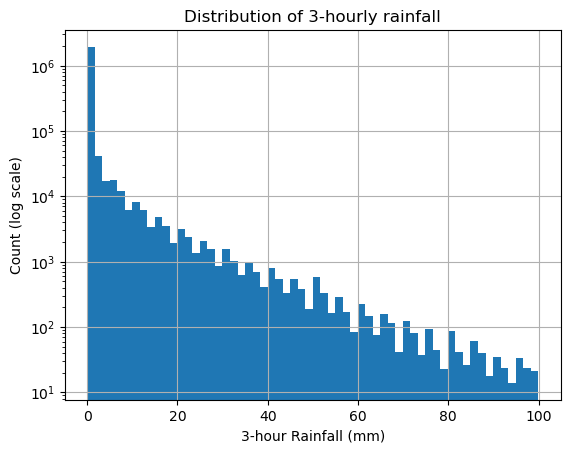

In [ ]:
import matplotlib.pyplot as plt

df_rain["Rainfall"].hist(bins=60, log=True)
plt.xlabel("3-hour Rainfall (mm)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of 3-hourly rainfall")
plt.show()


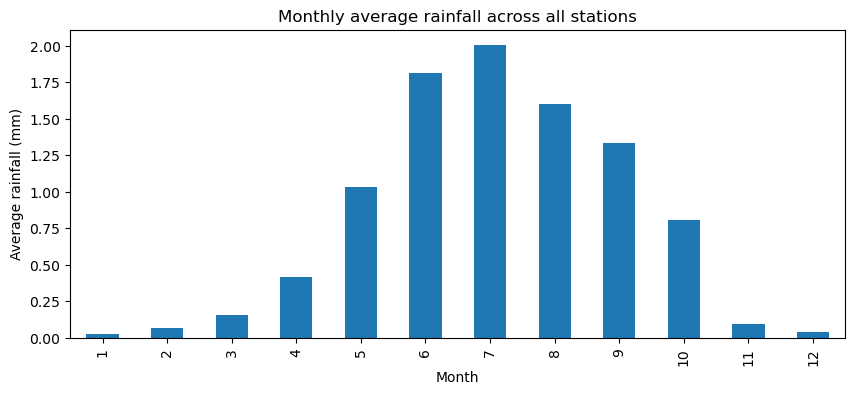

In [ ]:
monthly = df_rain.groupby("Month")["Rainfall"].mean()

monthly.plot(kind="bar", figsize=(10,4))
plt.ylabel("Average rainfall (mm)")
plt.title("Monthly average rainfall across all stations")
plt.show()


In [ ]:
threshold_95 = df_rain["Rainfall"].quantile(0.95)
threshold_99 = df_rain["Rainfall"].quantile(0.99)

threshold_95, threshold_99


(3.4, 21.0)

In [ ]:
gaps = (
    df_rain.sort_values("Datetime")
           .groupby("StationID")["Datetime"]
           .diff()
)

gaps_in_hours = gaps.dt.total_seconds() / 3600
gaps_in_hours.value_counts().head(10)


3.0       2069584
6.0           237
24.0            8
7347.0          1
8763.0          1
723.0           1
747.0           1
Name: Datetime, dtype: int64

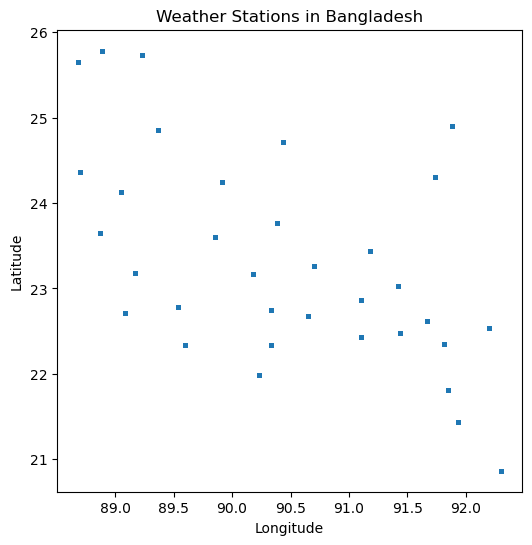

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df_rain["Longitude"], df_rain["Latitude"], s=5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Weather Stations in Bangladesh")
plt.show()


In [ ]:
station_mean = df_rain.groupby("StationID")["Rainfall"].mean()

station_mean.describe(), station_mean.sort_values().head(), station_mean.sort_values().tail()


(count    34.000000
 mean      0.789961
 std       0.257914
 min       0.434223
 25%       0.607140
 50%       0.697358
 75%       0.960748
 max       1.377476
 Name: Rainfall, dtype: float64,
 StationID
 10320    0.434223
 10910    0.473204
 41926    0.477689
 11505    0.537464
 10408    0.554707
 Name: Rainfall, dtype: float64,
 StationID
 11814    1.142311
 11927    1.177409
 11916    1.213818
 11929    1.374957
 10705    1.377476
 Name: Rainfall, dtype: float64)

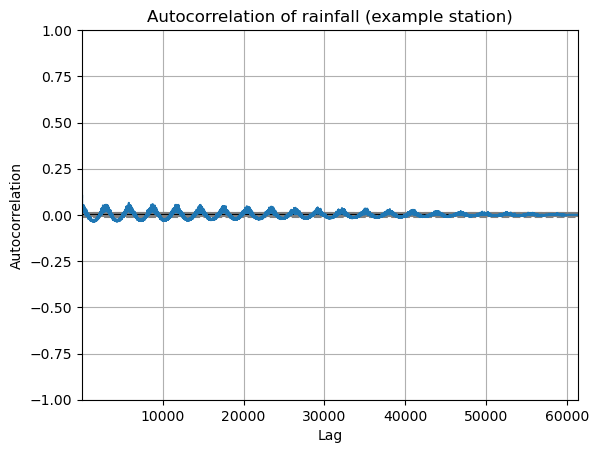

In [ ]:
example_station = df_rain["StationID"].iloc[0]
series = df_rain[df_rain["StationID"] == example_station]["Rainfall"]

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(series)
plt.title("Autocorrelation of rainfall (example station)")
plt.show()


In [ ]:
import numpy as np

is_heavy = df_rain["Rainfall"] >= 20  # example heavy threshold
run_length = np.diff(np.where(np.concatenate(([is_heavy.iloc[0]],
      is_heavy.to_numpy()[:-1] != is_heavy.to_numpy()[1:], [True]))))[::2]

run_length[:20]


array([[   2,  402,    1, ...,   27,    1, 6069]], dtype=int64)

In [ ]:
df_rain.groupby("Season")["Rainfall"].quantile(0.99)


Season
Monsoon         32.0
Post-Monsoon    13.8
Pre-Monsoon     17.0
Winter           0.4
Name: Rainfall, dtype: float64

In [ ]:
df_rain["Rainfall"].sort_values(ascending=False).head(10)


1038533    99.9
185574     99.8
1833540    99.8
1833092    99.4
1833093    99.4
1041784    99.2
1237462    99.2
122186     99.0
121371     99.0
865015     99.0
Name: Rainfall, dtype: float64

# **Hyperparameter Training**

In [ ]:
# ============================================================
# BanglaRain-ENS + Hyperparameter Tuning (Publication-ready style)
# Missingness-aware + Physics-aligned + Probabilistic
# Spatiotemporal Graph Transformer for 3h–24h rainfall + extreme risk
#
# ✅ DOES NOT change the ORIGINAL model structure
# ✅ Adds Hyperparameter Tuning (resume-safe + fixed-per-trial hp):
#    - fixed-per-trial hyperparams saved FIRST (trial_03 always same on rerun)
#    - resume-safe: skips trials that already have best_model.pt
#    - saves BEST checkpoint per trial + epoch logs
#    - writes tuning_summary.csv + best_trial.json
#
# ✅ UPDATED: Best-trial selection now considers BOTH:
#    - probabilistic rainfall forecasting (val CRPS_log)
#    - extreme-risk detection (mean Brier over flash/peak/acc)
#    via a normalized composite objective (default 0.5 / 0.5 weights)
#
# Objective (composite, lower is better):
#   composite_obj = 0.5*norm(CRPS_log) + 0.5*norm(mean_brier)
# ============================================================

import math
import random
import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# ✅ As original
set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 0.5) Mount Google Drive (Colab)
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving tuning results to:", SAVE_DIR)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (UNCHANGED)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Training / Evaluation
# ============================================================

def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, edge_index, optimizer, quantiles, weights, device):
    model.train()
    total = 0.0
    nb = 0

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # Quantile loss on log-rain
        q_losses = []
        for k, qv in enumerate(quantiles):
            q_losses.append(pinball_loss(q_hat[..., k], y_log, qv, mask=my))
        loss_q = torch.stack(q_losses).mean()

        # Risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # Crossing penalty (meaningful because we do NOT sort)
        q10 = q_hat[..., 0]
        q50 = q_hat[..., 1] if q_hat.size(-1) > 1 else q10
        q90 = q_hat[..., 2] if q_hat.size(-1) > 2 else q50
        phys_pen = (F.relu(q10 - q50) + F.relu(q50 - q90))
        phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak +
            weights["lambda_acc"]   * loss_acc +
            weights["lambda_phys"]  * phys_pen
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1

    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Main runner (kept for final training later)
# ============================================================

def run_banglarain_ens(
    df_rain,
    k_nn=4,
    T_in=16,
    H_out=8,
    quantiles=(0.1, 0.5, 0.9),
    train_frac=0.7,
    val_frac=0.15,
    batch_size=32,
    lr=1e-3,
    epochs=20,
    d_model=96,
    seed=42,
    deterministic=False,
):
    set_seed(seed, deterministic=deterministic)

    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=k_nn)
    edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)
    print("edge_index:", edge_index.shape)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    print("Split:")
    print("  Train: 0 →", train_end)
    print("  Val:  ", train_end, "→", val_end)
    print("  Test: ", val_end, "→", T)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=H_out)
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=T_in, H_out=H_out
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=T_in, H_out=H_out
    )
    ds_test = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=val_end, t_end=T,
        T_in=T_in, H_out=H_out
    )

    print("Dataset sizes:", len(ds_train), len(ds_val), len(ds_test))

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]
    print("Input feature dim:", F_in)

    # pos_weight from TRAIN only
    flash_all, mflash_all = [], []
    peak_all,  mpeak_all  = [], []
    acc_all,   macc_all   = [], []

    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash)
        mflash_all.append(mflash)
        peak_all.append(peak)
        mpeak_all.append(mpeak)
        acc_all.append(acc)
        macc_all.append(macc)

    flash_all = torch.cat(flash_all, dim=0)
    mflash_all = torch.cat(mflash_all, dim=0)
    peak_all = torch.cat(peak_all, dim=0)
    mpeak_all = torch.cat(mpeak_all, dim=0)
    acc_all = torch.cat(acc_all, dim=0)
    macc_all = torch.cat(macc_all, dim=0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    print("pos_weight flash:", float(pos_w_flash))
    print("pos_weight peak :", float(pos_w_peak))
    print("pos_weight acc  :", float(pos_w_acc))

    model = BanglaRainENS(
        num_stations=N,
        in_features=F_in,
        T_in=T_in,
        H_out=H_out,
        num_seasons=len(prep["unique_seasons"]),
        quantiles=quantiles,
        d_model=d_model,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    weights = {
        "lambda_q": 1.0,
        "lambda_flash": 2.0,
        "lambda_peak":  2.0,
        "lambda_acc":   2.0,
        "lambda_phys":  0.2,
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = math.inf
    best_state = None

    for ep in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, edge_index, optimizer, quantiles, weights, device)
        val_scores = evaluate(model, val_loader, edge_index, quantiles, device)

        val_key = val_scores["CRPS_log"]
        improved = val_key < best_val
        if improved:
            best_val = val_key
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {ep:02d} | train_loss={tr_loss:.4f} | "
            f"val_CRPS(log)={val_scores['CRPS_log']:.4f} | "
            f"val_CRPS(mm)={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f} | "
            f"{'BEST' if improved else ''}"
        )

        fm = val_scores["Flash_metrics"]
        if fm["pr_auc"] == fm["pr_auc"]:
            print(f"   Val Flash PR-AUC: {fm['pr_auc']:.4f} (n_valid={fm['n_valid']})")

    if best_state is not None:
        model.load_state_dict(best_state)
        print("Loaded best model by val CRPS(log):", best_val)

    test_scores = evaluate(model, test_loader, edge_index, quantiles, device)
    return model, prep, scaler, (thr3h, thrAcc24), test_scores


# ============================================================
# 8.5) Hyperparameter Tuning (does NOT modify model structure)
# ============================================================

def build_model_and_optimizer_from_hp(hp, N, F_in, num_seasons):
    model = BanglaRainENS(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=num_seasons,
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        n_heads=hp["n_heads"],
        num_temporal_layers=hp["num_temporal_layers"],
        num_gat_layers=hp["num_gat_layers"],
        gat_heads=hp["gat_heads"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )
    return model, optimizer


def sample_hparams(rng):
    H_out = 8  # fixed for 24h = 8×3h

    d_model = int(rng.choice([64, 128]))
    n_heads_candidates = [h for h in [2, 4, 8] if d_model % h == 0]
    n_heads = int(rng.choice(n_heads_candidates))

    hp = {
        "k_nn": int(rng.choice([3, 4, 5, 6, 7])),
        "T_in": int(rng.choice([16, 24, 32])),
        "H_out": H_out,

        "d_model": d_model,
        "dropout": float(rng.choice([0.1, 0.2, 0.3])),

        "n_heads": n_heads,
        "num_temporal_layers": int(rng.choice([1, 2])),  # CPU-safe
        "num_gat_layers": int(rng.choice([1, 2])),       # CPU-safe
        "gat_heads": int(rng.choice([1, 2])),            # CPU-safe

        "lr": float(rng.choice([5e-4, 1e-3, 2e-3])),
        "weight_decay": float(rng.choice([1e-5, 1e-4])),

        "lambda_q": 1.0,
        "lambda_flash": 2.0,
        "lambda_peak": 2.0,
        "lambda_acc": 2.0,
        "lambda_phys": float(rng.choice([0.0, 0.1, 0.25])),

        "batch_size": int(rng.choice([8, 16])),  # CPU-safe
        "epochs": 10,

        "quantiles": (0.1, 0.5, 0.9),
    }

    # CPU time safety (optional): avoid the heaviest combo
    if hp["T_in"] == 32 and hp["d_model"] == 128:
        hp["batch_size"] = 8

    return hp


def run_one_trial(df_rain, trial_id, hp, trial_dir, base_seed=42):
    # reproducibility per trial
    set_seed(base_seed + trial_id, deterministic=False)

    # Prepare data objects for this trial (depends on k_nn, T_in, H_out)
    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=hp["k_nn"])
    edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=hp["batch_size"], shuffle=False)

    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]

    # pos weights from TRAIN only
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    model, optimizer = build_model_and_optimizer_from_hp(
        hp, N=N, F_in=F_in, num_seasons=len(prep["unique_seasons"])
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None  # ✅ store metrics at best CRPS epoch
    trial_log = []

    for ep in range(1, hp["epochs"] + 1):
        tr_loss = train_one_epoch(
            model, train_loader, edge_index, optimizer,
            quantiles=hp["quantiles"], weights=weights, device=device
        )
        val_scores = evaluate(
            model, val_loader, edge_index,
            quantiles=hp["quantiles"], device=device
        )

        val_key = float(val_scores["CRPS_log"])
        trial_log.append({
            "trial": trial_id,
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
        })

        print(f"[Trial {trial_id:02d}] Epoch {ep:02d} | train={tr_loss:.4f} | val_CRPS_log={val_key:.4f}")

        if val_key < best_val:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Save trial artifacts
    ckpt_path = os.path.join(trial_dir, "best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,  # ✅ includes Brier at best epoch
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
    }, ckpt_path)

    pd.DataFrame(trial_log).to_csv(os.path.join(trial_dir, "epoch_log.csv"), index=False)

    # Return best-epoch metrics for global selection
    return {
        "trial": int(trial_id),
        "best_val_CRPS_log": float(best_val),
        "best_epoch": int(best_epoch),
        "ckpt_path": ckpt_path,
        "val_Brier_flash": float(best_metrics["Brier_flash"]) if best_metrics is not None else np.nan,
        "val_Brier_peak":  float(best_metrics["Brier_peak"])  if best_metrics is not None else np.nan,
        "val_Brier_acc":   float(best_metrics["Brier_acc"])   if best_metrics is not None else np.nan,
        **hp
    }


def tune_banglarain(df_rain, n_trials=10, base_seed=42):
    rng = np.random.RandomState(base_seed)

    summary_path = os.path.join(SAVE_DIR, "tuning_summary.csv")
    all_results = []

    # Resume summary if exists
    if os.path.exists(summary_path):
        try:
            existing = pd.read_csv(summary_path)
            if len(existing) > 0 and "trial" in existing.columns:
                all_results = existing.to_dict("records")
                print(f"✅ Found existing tuning_summary.csv with {len(existing)} rows (resume mode).")
        except Exception as e:
            print("⚠️ Could not load existing tuning_summary.csv. Starting fresh.", str(e))

    for t in range(n_trials):
        trial_dir = os.path.join(SAVE_DIR, f"trial_{t:02d}")
        os.makedirs(trial_dir, exist_ok=True)

        hp_path = os.path.join(trial_dir, "hparams.json")
        ckpt_path = os.path.join(trial_dir, "best_model.pt")

        # Skip completed trials
        if os.path.exists(ckpt_path):
            print(f"[Trial {t:02d}] ✅ best_model.pt exists -> skipping.")
            continue

        # Fixed-per-trial hp: reuse if exists, else sample and SAVE FIRST
        if os.path.exists(hp_path):
            with open(hp_path, "r") as f:
                hp = json.load(f)
            print(f"\n[Trial {t:02d}] ✅ Reusing saved hyperparameters: {hp_path}")
        else:
            hp = sample_hparams(rng)
            with open(hp_path, "w") as f:
                json.dump(hp, f, indent=2)
            print(f"\n[Trial {t:02d}] 💾 Sampled+saved hyperparameters: {hp_path}")

        print("\n" + "="*80)
        print(f"Starting Trial {t:02d} with hparams:")
        print(hp)
        print("="*80)

        try:
            res = run_one_trial(df_rain, trial_id=t, hp=hp, trial_dir=trial_dir, base_seed=base_seed)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"[Trial {t:02d}] CUDA OOM. Skipping trial (hp kept).")
                torch.cuda.empty_cache()
                continue
            else:
                raise e

        all_results.append(res)
        pd.DataFrame(all_results).to_csv(summary_path, index=False)

    # Load final summary (whatever exists now)
    if os.path.exists(summary_path):
        results_df = pd.read_csv(summary_path)
    else:
        results_df = pd.DataFrame(all_results)

    if len(results_df) == 0:
        raise RuntimeError("No successful trials completed.")

    # ============================================================
    # ✅ UPDATED BEST TRIAL SELECTION (CRPS + Risk Brier)
    # ============================================================
    eps = 1e-12

    has_brier_cols = all(
        c in results_df.columns for c in ["val_Brier_flash", "val_Brier_peak", "val_Brier_acc"]
    )

    if has_brier_cols:
        results_df["mean_brier"] = (
            results_df["val_Brier_flash"].astype(float) +
            results_df["val_Brier_peak"].astype(float) +
            results_df["val_Brier_acc"].astype(float)
        ) / 3.0

        crps = results_df["best_val_CRPS_log"].astype(float)
        bri  = results_df["mean_brier"].astype(float)

        crps_n = (crps - crps.min()) / (crps.max() - crps.min() + eps)
        bri_n  = (bri  - bri.min())  / (bri.max()  - bri.min()  + eps)

        w_crps = 0.5
        w_risk = 0.5
        results_df["composite_obj"] = w_crps * crps_n + w_risk * bri_n

        # Sort by composite objective
        results_df = results_df.sort_values("composite_obj", ascending=True)
    else:
        print("⚠️ Brier columns not found in summary; selecting best trial by best_val_CRPS_log only.")
        results_df = results_df.sort_values("best_val_CRPS_log", ascending=True)

    # Save ranked summary
    results_df.to_csv(summary_path, index=False)

    best = results_df.iloc[0].to_dict()
    with open(os.path.join(SAVE_DIR, "best_trial.json"), "w") as f:
        json.dump(best, f, indent=2)

    print("\n✅ Tuning finished.")
    print("Best trial:", int(best["trial"]))
    if "composite_obj" in best:
        print("Best composite objective:", best["composite_obj"])
    print("Best val CRPS_log:", best["best_val_CRPS_log"])
    if "mean_brier" in best:
        print("Best mean Brier (flash/peak/acc):", best["mean_brier"])
    print("Checkpoint:", best["ckpt_path"])

    return results_df, best


# ============================================================
# 9) Run
# ============================================================

# (1) Hyperparameter tuning:
# results_df, best_trial = tune_banglarain(df_rain, n_trials=10, base_seed=42)

# (2) Final training (optional): after tuning, plug best_trial params into run_banglarain_ens
# model, prep, scaler, thresholds, test_scores = run_banglarain_ens(
#     df_rain,
#     k_nn=int(best_trial["k_nn"]),
#     T_in=int(best_trial["T_in"]),
#     H_out=int(best_trial["H_out"]),
#     quantiles=tuple(best_trial["quantiles"]),
#     batch_size=int(best_trial["batch_size"]),
#     lr=float(best_trial["lr"]),
#     epochs=20,              # you can increase for final run
#     d_model=int(best_trial["d_model"]),
#     seed=42,
#     deterministic=False,
# )


Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving tuning results to: /content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1


In [ ]:
results_df, best_trial = tune_banglarain(df_rain, n_trials=15, base_seed=42)


✅ Found existing tuning_summary.csv with 13 rows (resume mode).
[Trial 00] ✅ best_model.pt exists -> skipping.
[Trial 01] ✅ best_model.pt exists -> skipping.
[Trial 02] ✅ best_model.pt exists -> skipping.
[Trial 03] ✅ best_model.pt exists -> skipping.
[Trial 04] ✅ best_model.pt exists -> skipping.
[Trial 05] ✅ best_model.pt exists -> skipping.
[Trial 06] ✅ best_model.pt exists -> skipping.
[Trial 07] ✅ best_model.pt exists -> skipping.
[Trial 08] ✅ best_model.pt exists -> skipping.
[Trial 09] ✅ best_model.pt exists -> skipping.
[Trial 10] ✅ best_model.pt exists -> skipping.
[Trial 11] ✅ best_model.pt exists -> skipping.
[Trial 12] ✅ best_model.pt exists -> skipping.

[Trial 13] ✅ Reusing saved hyperparameters: /content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1/trial_13/hparams.json

Starting Trial 13 with hparams:
{'k_nn': 3, 'T_in': 32, 'H_out': 8, 'd_model': 64, 'dropout': 0.3, 'n_heads': 2, 'num_temporal_layers': 1, 'num_gat_layers': 2, 'gat_heads': 2, 'lr': 0.002, 'wei

/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 13] Epoch 01 | train=4.8334 | val_CRPS_log=0.1465


/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 13] Epoch 02 | train=4.6799 | val_CRPS_log=0.1415


...

[Trial 14] Epoch 08 | train=4.3972 | val_CRPS_log=0.1381


/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 09 | train=4.3853 | val_CRPS_log=0.1429


/tmp/ipython-input-3317001930.py:426: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Epoch 10 | train=4.3765 | val_CRPS_log=0.1393

✅ Tuning finished.
Best trial: 4
Best composite objective: 0.05589926324180735
Best val CRPS_log: 0.1354140129535806
Best mean Brier (flash/peak/acc): 0.136490625333202
Checkpoint: /content/drive/MyDrive/Rainfall/BanglaRainENS/Tuning_Results/v1/trial_04/best_model.pt


# Training code

In [ ]:
# ============================================================
# BanglaRain-ENS: Final Training Script (Standalone)
# ------------------------------------------------------------
# - Assumes df_rain is already loaded in memory (DataFrame)
# - Assumes best_trial.json exists (from previous tuning) at:
#     SAVE_DIR/best_trial.json
# - Loads best hyperparameters
# - Trains final model with:
#     * early stopping on val CRPS_log
#     * per-epoch metrics printed + logged
# - Saves to Google Drive:
#     * final_epoch_log.csv
#     * final_best_model.pt
# ============================================================

import math
import random
import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Path where tuning saved best_trial.json
SAVE_DIR = r"C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\BanglaRainENS\Tuning_Results\v1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Tuning results directory:", SAVE_DIR)

# Path where final model + logs will be saved
FINAL_SAVE_DIR = r"C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\BanglaRainENS\Final_Run\v2"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)
print("Final run artifacts will be saved to:", FINAL_SAVE_DIR)

# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }

# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }

# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler

# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )

# ============================================================
# 6) Model
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits

# ============================================================
# 7) Training / Evaluation
# ============================================================

def compute_pos_weight(labels, masks):
    with torch.no_grad():
        pos = (labels * masks).sum().item()
        tot = masks.sum().item()
        neg = tot - pos
        if pos < 1:
            return 1.0
        w = (neg + 1e-6) / (pos + 1e-6)
        return float(np.clip(w, 1.0, 30.0))


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)


def train_one_epoch(model, loader, edge_index, optimizer, quantiles, weights, device):
    model.train()
    total = 0.0
    nb = 0

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        optimizer.zero_grad()
        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # Quantile loss on log-rain
        q_losses = []
        for k, qv in enumerate(quantiles):
            q_losses.append(pinball_loss(q_hat[..., k], y_log, qv, mask=my))
        loss_q = torch.stack(q_losses).mean()

        # Risk losses
        loss_flash = masked_bce_with_logits(flash_logits, flash, mflash, weights["pos_w_flash"])
        loss_peak  = masked_bce_with_logits(peak_logits,  peak,  mpeak,  weights["pos_w_peak"])
        loss_acc   = masked_bce_with_logits(acc_logits,   acc,   macc,   weights["pos_w_acc"])

        # Crossing penalty (dynamic for any number of quantiles)
        phys_pen = 0.0
        for i in range(len(quantiles) - 1):
            # Penalize if a lower quantile output is greater than the next higher quantile
            phys_pen += F.relu(q_hat[..., i] - q_hat[..., i+1])

        if isinstance(phys_pen, torch.Tensor):
            phys_pen = (phys_pen * my).sum() / my.sum().clamp_min(1.0)

        loss = (
            weights["lambda_q"]     * loss_q +
            weights["lambda_flash"] * loss_flash +
            weights["lambda_peak"]  * loss_peak +
            weights["lambda_acc"]   * loss_acc +
            weights["lambda_phys"]  * phys_pen
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1

    return total / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out

# ============================================================
# 8) Hyperparams loader (from best_trial.json)
# ============================================================

def load_best_hparams(best_trial_path):
    """
    Load best_trial.json and build a clean hp dict with proper dtypes.
    Ignores any stored 'quantiles' and fixes to (0.1, 0.5, 0.9).
    """
    with open(best_trial_path, "r") as f:
        best = json.load(f)

    hp = {
        "k_nn": int(best["k_nn"]),
        "T_in": int(best["T_in"]),
        "H_out": int(best["H_out"]),
        "d_model": int(best["d_model"]),
        "dropout": float(best["dropout"]),
        "n_heads": int(best["n_heads"]),
        "num_temporal_layers": int(best["num_temporal_layers"]),
        "num_gat_layers": int(best["num_gat_layers"]),
        "gat_heads": int(best["gat_heads"]),
        "lr": float(best["lr"]),
        "weight_decay": float(best["weight_decay"]),
        "lambda_q": float(best.get("lambda_q", 1.0)),
        "lambda_flash": float(best.get("lambda_flash", 2.0)),
        "lambda_peak": float(best.get("lambda_peak", 2.0)),
        "lambda_acc": float(best.get("lambda_acc", 2.0)),
        "lambda_phys": float(best.get("lambda_phys", 0.1)),
        "batch_size": int(best["batch_size"]),
        # epochs is max epochs; can override
        "epochs": int(best.get("epochs", 10)),
        "quantiles": (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
    }
    return hp

# ============================================================
# 9) Final training with early stopping
# ============================================================

def final_train_banglarain(df_rain,
                           hp,
                           final_save_dir=FINAL_SAVE_DIR,
                           train_frac=0.7,
                           val_frac=0.15,
                           base_seed=42,
                           max_epochs=None,
                           patience=5):
    """
    Final training run with fixed hyperparameters (hp).
    - Uses same preprocessing as tuning.
    - Early stopping on val CRPS_log with given patience.
    - Saves:
        * final_best_model.pt  (state_dict + scaler + thresholds + meta)
        * final_epoch_log.csv  (epoch-wise metrics)
    """
    if max_epochs is None:
        max_epochs = hp["epochs"]

    # Reproducibility
    set_seed(base_seed, deterministic=False)

    # 1) Preprocessing
    prep = prepare_full_grid(df_rain)
    stations = prep["stations"]
    N = len(stations)

    edge_index_np = build_knn_graph(stations, k=hp["k_nn"])
    edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac=train_frac, val_frac=val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )
    ds_val = BanglaRainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        prep["season_ids"],
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=hp["T_in"], H_out=hp["H_out"]
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=hp["batch_size"], shuffle=False)

    # Infer input feature dim
    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]

    # 2) Pos-weights from training data
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, _, _, _, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all),  device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all),   device=device)

    # 3) Build model + optimizer from hp
    model = BanglaRainENS(
        num_stations=N,
        in_features=F_in,
        T_in=hp["T_in"],
        H_out=hp["H_out"],
        num_seasons=len(prep["unique_seasons"]),
        quantiles=hp["quantiles"],
        d_model=hp["d_model"],
        n_heads=hp["n_heads"],
        num_temporal_layers=hp["num_temporal_layers"],
        num_gat_layers=hp["num_gat_layers"],
        gat_heads=hp["gat_heads"],
        dropout=hp["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    # 4) Training loop with early stopping
    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    epoch_log = []
    epochs_since_improve = 0

    for ep in range(1, max_epochs + 1):
        tr_loss = train_one_epoch(
            model, train_loader, edge_index, optimizer,
            quantiles=hp["quantiles"], weights=weights, device=device
        )
        val_scores = evaluate(
            model, val_loader, edge_index,
            quantiles=hp["quantiles"], device=device
        )

        val_key = float(val_scores["CRPS_log"])

        # Flatten some event metrics for logging
        fm = val_scores["Flash_metrics"]
        pm = val_scores["Peak24_metrics"]
        am = val_scores["Acc24_metrics"]

        row = {
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
            "flash_pr_auc": float(fm.get("pr_auc", np.nan)),
            "flash_roc_auc": float(fm.get("roc_auc", np.nan)),
            "peak_pr_auc": float(pm.get("pr_auc", np.nan)),
            "peak_roc_auc": float(pm.get("roc_auc", np.nan)),
            "acc_pr_auc": float(am.get("pr_auc", np.nan)),
            "acc_roc_auc": float(am.get("roc_auc", np.nan)),
            "flash_n_valid": int(fm.get("n_valid", 0)),
            "peak_n_valid": int(pm.get("n_valid", 0)),
            "acc_n_valid": int(am.get("n_valid", 0)),
        }
        epoch_log.append(row)

        print(
            f"[FINAL] Epoch {ep:02d} | "
            f"train={tr_loss:.4f} | "
            f"val_CRPS_log={val_key:.4f} | "
            f"val_CRPS_mm={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f}"
        )

        # Check improvement
        if val_key < best_val - 1e-6:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
            improved = True
        else:
            epochs_since_improve += 1
            improved = False

        if improved:
            print(f"   -> New best epoch {ep:02d} (val_CRPS_log={best_val:.4f})")
        else:
            print(f"   -> No improvement for {epochs_since_improve} epoch(s)")

        # Save epoch log after each epoch (safe vs Colab disconnects)
        log_path = os.path.join(final_save_dir, "final_epoch_log.csv")
        pd.DataFrame(epoch_log).to_csv(log_path, index=False)

        # Early stopping check
        if epochs_since_improve >= patience:
            print(f"\n[EARLY STOP] No improvement in {patience} epochs. Stopping at epoch {ep}.")
            break

    # 5) Save best model checkpoint for reuse
    ckpt_path = os.path.join(final_save_dir, "final_best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
        "thr3h": thr3h,
        "thrAcc24": thrAcc24,
        "stations": prep["stations"],
        "times": prep["times"],
    }, ckpt_path)

    print("\n[FINAL] Training finished.")
    print("Best epoch:", best_epoch, "| best val CRPS_log:", best_val)
    print("Checkpoint saved to:", ckpt_path)
    print("Epoch log saved to:", log_path)

    return {
        "best_epoch": best_epoch,
        "best_val_CRPS_log": best_val,
        "ckpt_path": ckpt_path,
        "log_path": log_path,
        "hp": hp,
    }

# ============================================================
# 10) Run final training (example)
# ============================================================

# Assumes df_rain (your big 3-hourly DataFrame) is already in memory.
# Assumes best_trial.json exists in SAVE_DIR from your previous tuning.

best_trial_path = os.path.join(SAVE_DIR, "best_trial.json")
best_hp = load_best_hparams(best_trial_path)

# Optionally override max epochs for final run
best_hp["epochs"] = 50  # e.g., 30 epochs max

final_results = final_train_banglarain(
    df_rain=df_rain,
    hp=best_hp,
    final_save_dir=FINAL_SAVE_DIR,
    train_frac=0.7,
    val_frac=0.15,
    base_seed=42,
    max_epochs=best_hp["epochs"],
    patience=10,   # early stopping patience
)

print("\nFinal results summary:")
print(final_results)


Using device: cuda
Tuning results directory: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\BanglaRainENS\Tuning_Results\v1
Final run artifacts will be saved to: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\BanglaRainENS\Final_Run\v2
Total stations: 34
Total unique times: 61360


C:\Users\deepn\AppData\Local\Temp\ipykernel_24784\2977167036.py:413: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 01 | train=4.6577 | val_CRPS_log=0.1325 | val_CRPS_mm=0.6817 | val_BS_flash=0.1356 | val_BS_peak=0.1620 | val_BS_acc=0.1547
   -> New best epoch 01 (val_CRPS_log=0.1325)


C:\Users\deepn\AppData\Local\Temp\ipykernel_24784\2977167036.py:413: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 02 | train=4.4317 | val_CRPS_log=0.1293 | val_CRPS_mm=0.6764 | val_BS_flash=0.1244 | val_BS_peak=0.1512 | val_BS_acc=0.1358
   -> New best epoch 02 (val_CRPS_log=0.1293)


...

[FINAL] Epoch 26 | train=3.9706 | val_CRPS_log=0.1270 | val_CRPS_mm=0.6813 | val_BS_flash=0.1381 | val_BS_peak=0.1632 | val_BS_acc=0.1451
   -> No improvement for 8 epoch(s)


C:\Users\deepn\AppData\Local\Temp\ipykernel_24784\2977167036.py:413: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 27 | train=3.9660 | val_CRPS_log=0.1273 | val_CRPS_mm=0.6768 | val_BS_flash=0.1197 | val_BS_peak=0.1570 | val_BS_acc=0.1453
   -> No improvement for 9 epoch(s)


C:\Users\deepn\AppData\Local\Temp\ipykernel_24784\2977167036.py:413: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL] Epoch 28 | train=3.9527 | val_CRPS_log=0.1267 | val_CRPS_mm=0.6848 | val_BS_flash=0.1307 | val_BS_peak=0.1629 | val_BS_acc=0.1610
   -> No improvement for 10 epoch(s)

[EARLY STOP] No improvement in 10 epochs. Stopping at epoch 28.

[FINAL] Training finished.
Best epoch: 18 | best val CRPS_log: 0.12582068036282792
Checkpoint saved to: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\BanglaRainENS\Final_Run\v2\final_best_model.pt
Epoch log saved to: C:\Users\deepn\Documents\Rainfall_Training_Research_Lab\BanglaRainENS\Final_Run\v2\final_epoch_log.csv

Final results summary:
{'best_epoch': 18, 'best_val_CRPS_log': 0.12582068036282792, 'ckpt_path': 'C:\\Users\\deepn\\Documents\\Rainfall_Training_Research_Lab\\BanglaRainENS\\Final_Run\\v2\\final_best_model.pt', 'log_path': 'C:\\Users\\deepn\\Documents\\Rainfall_Training_Research_Lab\\BanglaRainENS\\Final_Run\\v2\\final_epoch_log.csv', 'hp': {'k_nn': 7, 'T_in': 24, 'H_out': 8, 'd_model': 64, 'dropout': 0.2, 'n_heads': 8, 'num

# Testing

Using device: cpu
Checkpoint path: C:\Users\pc\Documents\Rainfall\BanglaRainENS\Final_Run\v1\final_best_model.pt
Log path       : C:\Users\pc\Documents\Rainfall\BanglaRainENS\Final_Run\v1\final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1350
  best_epoch       : 7
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9173
Input feature dim: 18

Model rebuilt and weights loaded.


C:\Users\pc\AppData\Local\Temp\ipykernel_19148\2744003386.py:409: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



========== TEST METRICS ==========
CRPS_log   : 0.1145
CRPS_mm    : 0.5996
Brier_flash: 0.0955
Brier_peak : 0.1313
Brier_acc  : 0.1070

[Flash 3h]  PR-AUC=0.4041, ROC-AUC=0.9204, n_valid=307231
[Peak24]   PR-AUC=0.6168, ROC-AUC=0.8812, n_valid=307263
[Acc24]    PR-AUC=0.2653, ROC-AUC=0.8812, n_valid=306923

Loaded epoch log with 17 rows.


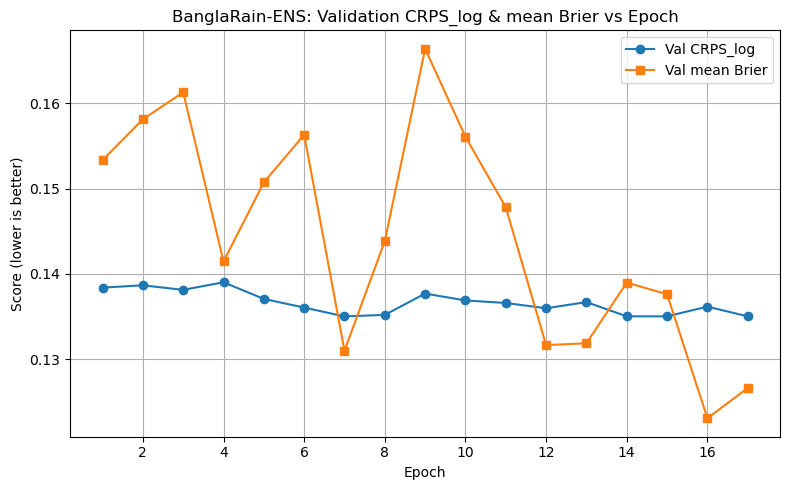

In [ ]:
# ============================================================
# BanglaRain-ENS — Standalone TESTING Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, and plot CRPS / Brier vs epoch.
#
# 👉 This file is SELF-CONTAINED:
#    - includes preprocessing functions
#    - dataset class
#    - model class
#    - evaluate()
#    - uses SAME model structure as tuning/training
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (SAME STRUCTURE AS TUNING/TRAINING)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Evaluation function
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Reload final model, rebuild TEST set, evaluate, plot
# ============================================================

FINAL_SAVE_DIR = r"C:\Users\pc\Documents\Rainfall\BanglaRainENS\Final_Run\v1"


CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 8.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
#ckpt = torch.load(CKPT_PATH, map_location=device)

hp = ckpt["hparams"]            # dict of best hyperparameters
state_dict = ckpt["state_dict"] # model weights

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")


# ---- 8.3 Rebuild preprocessing + TEST dataset ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# Train-only scaling (same as training)
X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

# Thresholds from TRAIN
thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

# Acc24 + thresholds
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))
thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

# Build TEST dataset
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test,
                         batch_size=int(hp["batch_size"]),
                         shuffle=False)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 8.4 Rebuild model and load weights ----
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 8.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
        device=device,
    )

print("\n========== TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

print("\n[Flash 3h]  PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    fm["pr_auc"], fm["roc_auc"], fm["n_valid"]
))
print("[Peak24]   PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    pm["pr_auc"], pm["roc_auc"], pm["n_valid"]
))
print("[Acc24]    PR-AUC={:.4f}, ROC-AUC={:.4f}, n_valid={}".format(
    am["pr_auc"], am["roc_auc"], am["n_valid"]
))

# ---- 8.6 Plot learning curves from final_epoch_log.csv ----
log_df = pd.read_csv(LOG_PATH)
print("\nLoaded epoch log with {} rows.".format(len(log_df)))

# Compute mean Brier (flash/peak/acc) per epoch
log_df["mean_brier"] = log_df[["val_Brier_flash",
                               "val_Brier_peak",
                               "val_Brier_acc"]].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
plt.xlabel("Epoch")
plt.ylabel("Score (lower is better)")
plt.title("BanglaRain-ENS: Validation CRPS_log & mean Brier vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Using device: cpu
Checkpoint path: /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_k7/v1/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_k7/v1/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1350
  best_epoch       : 7
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9173
Input feature dim: 18

Model rebuilt and weights loaded.


/tmp/ipython-input-1347973467.py:409: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



========== TEST METRICS ==========
CRPS_log   : 0.1145
CRPS_mm    : 0.5996
Brier_flash: 0.0955
Brier_peak : 0.1313
Brier_acc  : 0.1070

[Deterministic] Mean MAE:  0.6670 mm
[Deterministic] Mean RMSE: 3.9837 mm

[Flash 3h] PR-AUC=0.4041, ROC-AUC=0.9204
   @Thr=0.5: CSI=0.1952, POD=0.8086, FAR=0.7953

[Peak 24h] PR-AUC=0.6168, ROC-AUC=0.8812
   @Thr=0.5: CSI=0.4181, POD=0.8257, FAR=0.5415

[Acc 24h] PR-AUC=0.2653, ROC-AUC=0.8812
   @Thr=0.5: CSI=0.1541, POD=0.7136, FAR=0.8358

Loaded epoch log with 17 rows.


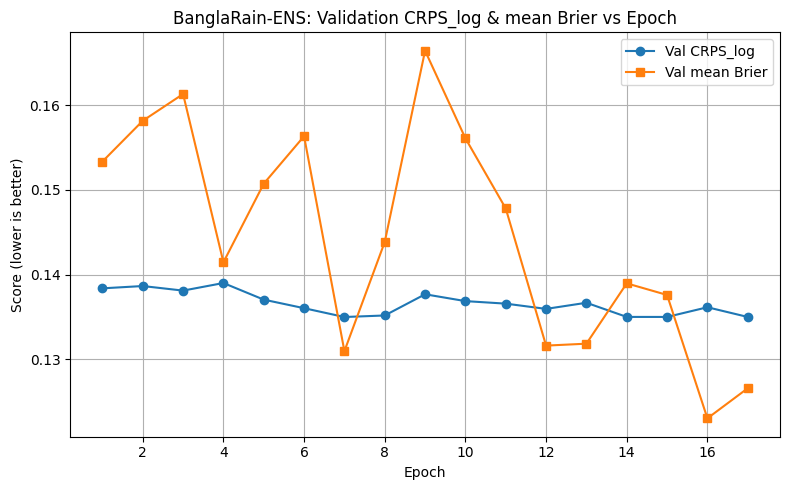

In [ ]:
# ============================================================
# BanglaRain-ENS — Standalone TESTING Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, and plot CRPS / Brier vs epoch.
#
# 👉 This file is SELF-CONTAINED:
#    - includes preprocessing functions
#    - dataset class
#    - model class
#    - evaluate()
#    - uses SAME model structure as tuning/training
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (SAME STRUCTURE AS TUNING/TRAINING)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.1, 0.5, 0.9),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Evaluation function
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # streaming mm MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Reload final model, rebuild TEST set, evaluate, plot
# ============================================================

FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_k7/v1"


CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 8.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
#ckpt = torch.load(CKPT_PATH, map_location=device)

hp = ckpt["hparams"]            # dict of best hyperparameters
state_dict = ckpt["state_dict"] # model weights

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")


# ---- 8.3 Rebuild preprocessing + TEST dataset ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# Train-only scaling (same as training)
X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

# Thresholds from TRAIN
thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

# Acc24 + thresholds
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))
thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

# Build TEST dataset
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test,
                         batch_size=int(hp["batch_size"]),
                         shuffle=False)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 8.4 Rebuild model and load weights ----
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 8.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.1, 0.5, 0.9))),
        device=device,
    )

print("\n========== TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

# --- NEW: Print MAE and RMSE ---
# These are lists (one value per forecast horizon). We print the mean.
maes = test_scores["MAE_mm_by_lead"]
rmses = test_scores["RMSE_mm_by_lead"]
print(f"\n[Deterministic] Mean MAE:  {np.nanmean(maes):.4f} mm")
print(f"[Deterministic] Mean RMSE: {np.nanmean(rmses):.4f} mm")
# Optional: print RMSE for specific lead times (e.g., 3h, 6h, 24h) if you want detail
# print(f"(RMSE per 3h step: {rmses})")

# --- NEW: Print CSI, POD, FAR for a specific decision threshold ---
# You can change target_thr to 0.3 or 0.5 depending on what you want to report
target_thr = 0.5

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

# Helper function to safely print metrics if the threshold exists
def print_event_metrics(name, metrics, thr):
    print(f"\n[{name}] PR-AUC={metrics['pr_auc']:.4f}, ROC-AUC={metrics['roc_auc']:.4f}")
    if thr in metrics["by_thr"]:
        m = metrics["by_thr"][thr]
        print(f"   @Thr={thr}: CSI={m['CSI']:.4f}, POD={m['POD']:.4f}, FAR={m['FAR']:.4f}")
    else:
        print(f"   @Thr={thr}: Metrics not found (available: {list(metrics['by_thr'].keys())})")

print_event_metrics("Flash 3h", fm, target_thr)
print_event_metrics("Peak 24h", pm, target_thr)
print_event_metrics("Acc 24h",  am, target_thr)

# ---- 8.6 Plot learning curves from final_epoch_log.csv ----
log_df = pd.read_csv(LOG_PATH)
print("\nLoaded epoch log with {} rows.".format(len(log_df)))

# Compute mean Brier (flash/peak/acc) per epoch
log_df["mean_brier"] = log_df[["val_Brier_flash",
                               "val_Brier_peak",
                               "val_Brier_acc"]].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
plt.xlabel("Epoch")
plt.ylabel("Score (lower is better)")
plt.title("BanglaRain-ENS: Validation CRPS_log & mean Brier vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Evaluation

Using device: cpu
Checkpoint path: /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_k7/v1/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Final_Run_k7/v1/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1350
  best_epoch       : 7
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9173
Input feature dim: 18

Model rebuilt and weights loaded.
Evaluating and generating test_predictions.npz...


/tmp/ipython-input-2724700431.py:409: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


Saved test_predictions.npz successfully.

========== TEST METRICS ==========
CRPS_log   : 0.1145
CRPS_mm    : 0.5996
Brier_flash: 0.0955
Brier_peak : 0.1313
Brier_acc  : 0.1070

[Deterministic] Mean MAE:  0.6670 mm
[Deterministic] Mean RMSE: 3.9837 mm
(MAE per 3h step: [0.6447616815567017, 0.663783848285675, 0.6676582098007202, 0.6709665656089783, 0.6709161996841431, 0.67268306016922, 0.6723155379295349, 0.6732248067855835])
(RMSE per 3h step: [3.8587942123413086, 3.9695582389831543, 3.990379571914673, 4.001976013183594, 4.008472442626953, 4.012176036834717, 4.013610363006592, 4.014373779296875])

[Flash 3h] PR-AUC=0.4041, ROC-AUC=0.9204
   @Thr=0.5: CSI=0.1952, POD=0.8086, FAR=0.7953

[Peak 24h] PR-AUC=0.6168, ROC-AUC=0.8812
   @Thr=0.5: CSI=0.4181, POD=0.8257, FAR=0.5415

[Acc 24h] PR-AUC=0.2653, ROC-AUC=0.8812
   @Thr=0.5: CSI=0.1541, POD=0.7136, FAR=0.8358

Loaded epoch log with 17 rows.


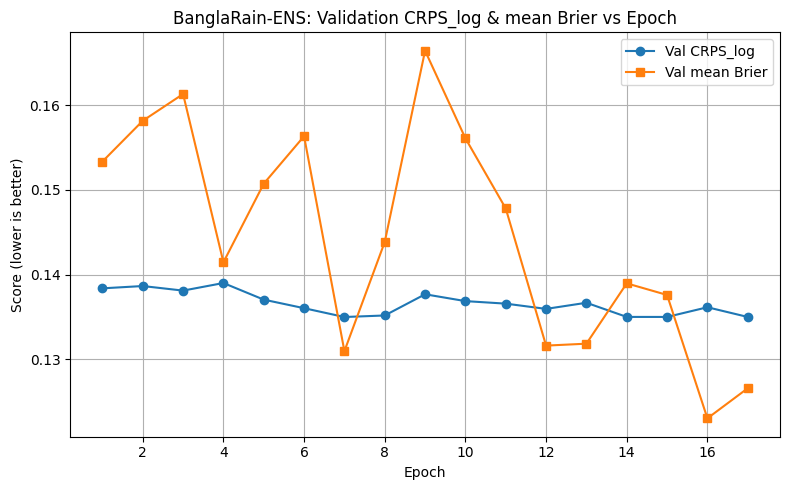

In [ ]:
# ============================================================
# BanglaRain-ENS — Standalone TESTING Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, and plot CRPS / Brier vs epoch.
#
# 👉 This file is SELF-CONTAINED:
#    - includes preprocessing functions
#    - dataset class
#    - model class
#    - evaluate()
#    - uses SAME model structure as tuning/training
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (SAME STRUCTURE AS TUNING/TRAINING)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Evaluation function
# ============================================================
# ============================================================
# 7) Evaluation function (Hybrid: Metrics + Saving)
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5), save_path="test_predictions.npz"):
    model.eval()

    # --- Metrics Accumulators ---
    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # Streaming MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    # --- Lists for Metrics Calculation ---
    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    # --- Lists for Saving to NPZ (Visualization) ---
    save_q_hat = []
    save_y_log = []
    save_flash_p = []
    save_flash_y = []

    # Station-wise error tracking for Spatial Map
    station_crps_sum = {}
    station_count_n = {}

    print(f"Evaluating and generating {save_path}...")

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        edge_index = edge_index.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # 1. Standard Probabilistic Metrics
        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()
        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()
        nb += 1

        # 2. Deterministic Metrics (MAE/RMSE)
        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)
        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        # 3. Collect Data for Final Metrics (POD/CSI)
        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))
        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))
        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

        # 4. Collect Data for Saving (Case Study / Spatial Map)
        # Move to CPU numpy
        q_hat_np = q_hat.detach().cpu().numpy()
        y_log_np = y_log.detach().cpu().numpy()
        mask_np  = my.detach().cpu().numpy()

        save_q_hat.append(q_hat_np)
        save_y_log.append(y_log_np)
        save_flash_p.append(p_flash.detach().cpu().numpy())
        save_flash_y.append(flash.detach().cpu().numpy())

        # Accumulate Station-wise CRPS (for Spatial Map)
        # Average over horizons and quantiles
        for n_idx in range(N):
            valid = mask_np[:, :, n_idx] > 0.5
            if not valid.any(): continue

            # Simple CRPS calc for this station in this batch
            loss_batch = 0
            cnt_batch = 0
            for k_idx, q_val in enumerate(quantiles):
                e = y_log_np[:, :, n_idx] - q_hat_np[:, :, n_idx, k_idx]
                loss = np.maximum((q_val - 1.0) * e, q_val * e)
                loss = loss * valid
                loss_batch += loss.sum()
                cnt_batch += valid.sum()

            if n_idx not in station_crps_sum:
                station_crps_sum[n_idx] = 0.0
                station_count_n[n_idx] = 0
            station_crps_sum[n_idx] += (loss_batch * 2.0)
            station_count_n[n_idx] += cnt_batch

    # --- END LOOP ---

    # A. Save NPZ File
    full_q_hat = np.concatenate(save_q_hat, axis=0)
    full_y_log = np.concatenate(save_y_log, axis=0)
    full_flash_p = np.concatenate(save_flash_p, axis=0) # [Samples, Nodes]
    full_flash_y = np.concatenate(save_flash_y, axis=0) # [Samples, Nodes]

    # Finalize Spatial CRPS
    station_crps_final = []
    for n_idx in range(len(station_crps_sum)):
        if station_count_n.get(n_idx, 0) > 0:
            station_crps_final.append(station_crps_sum[n_idx] / station_count_n[n_idx])
        else:
            station_crps_final.append(np.nan)

    np.savez(save_path,
             q_hat=full_q_hat,
             y_log=full_y_log,
             flash_p=full_flash_p.flatten(),
             flash_y=full_flash_y.flatten(),
             station_crps=np.array(station_crps_final))
    print(f"Saved {save_path} successfully.")

    # B. Compile Final Scores
    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()
    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()
    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Reload final model, rebuild TEST set, evaluate, plot
# ============================================================

FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v1"


CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 8.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
#ckpt = torch.load(CKPT_PATH, map_location=device)

hp = ckpt["hparams"]            # dict of best hyperparameters
state_dict = ckpt["state_dict"] # model weights

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")


# ---- 8.3 Rebuild preprocessing + TEST dataset ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# Train-only scaling (same as training)
X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

# Thresholds from TRAIN
thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)

# Acc24 + thresholds
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))
thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

# Build TEST dataset
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test,
                         batch_size=int(hp["batch_size"]),
                         shuffle=False)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 8.4 Rebuild model and load weights ----
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 8.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
        device=device,
    )

print("\n========== TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

# --- NEW: Print MAE and RMSE ---
# These are lists (one value per forecast horizon). We print the mean.
maes = test_scores["MAE_mm_by_lead"]
rmses = test_scores["RMSE_mm_by_lead"]
print(f"\n[Deterministic] Mean MAE:  {np.nanmean(maes):.4f} mm")
print(f"[Deterministic] Mean RMSE: {np.nanmean(rmses):.4f} mm")
# Optional: print MAE & RMSE for specific lead times (e.g., 3h, 6h, 24h) if you want detail
print(f"(MAE per 3h step: {maes})")
print(f"(RMSE per 3h step: {rmses})")

# --- NEW: Print CSI, POD, FAR for a specific decision threshold ---
# You can change target_thr to 0.3 or 0.5 depending on what you want to report
target_thr = 0.5

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

# Helper function to safely print metrics if the threshold exists
def print_event_metrics(name, metrics, thr):
    print(f"\n[{name}] PR-AUC={metrics['pr_auc']:.4f}, ROC-AUC={metrics['roc_auc']:.4f}")
    if thr in metrics["by_thr"]:
        m = metrics["by_thr"][thr]
        print(f"   @Thr={thr}: CSI={m['CSI']:.4f}, POD={m['POD']:.4f}, FAR={m['FAR']:.4f}")
    else:
        print(f"   @Thr={thr}: Metrics not found (available: {list(metrics['by_thr'].keys())})")

print_event_metrics("Flash 3h", fm, target_thr)
print_event_metrics("Peak 24h", pm, target_thr)
print_event_metrics("Acc 24h",  am, target_thr)

# ---- 8.6 Plot learning curves from final_epoch_log.csv ----
log_df = pd.read_csv(LOG_PATH)
print("\nLoaded epoch log with {} rows.".format(len(log_df)))

# Compute mean Brier (flash/peak/acc) per epoch
log_df["mean_brier"] = log_df[["val_Brier_flash",
                               "val_Brier_peak",
                               "val_Brier_acc"]].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
plt.xlabel("Epoch")
plt.ylabel("Score (lower is better)")
plt.title("BanglaRain-ENS: Validation CRPS_log & mean Brier vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Updated Evaluation

Using device: cpu
Checkpoint path: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1258
  best_epoch       : 18
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Test dataset size: 9173
Input feature dim: 18

Model rebuilt and weights loaded.
Evaluating and generating test_predictions.npz...


/tmp/ipykernel_9224/2060365959.py:409: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


Saved test_predictions.npz successfully.

========== TEST METRICS ==========
CRPS_log   : 0.1068
CRPS_mm    : 0.5726
Brier_flash: 0.1060
Brier_peak : 0.1345
Brier_acc  : 0.1247

[Deterministic] Mean MAE:  0.6665 mm
[Deterministic] Mean RMSE: 3.9633 mm
(MAE per 3h step: [0.6469877362251282, 0.6631993055343628, 0.665913462638855, 0.6681055426597595, 0.6704375743865967, 0.6741873621940613, 0.6720117330551147, 0.6714265942573547])
(RMSE per 3h step: [3.8643534183502197, 3.9345364570617676, 3.956847906112671, 3.9741830825805664, 3.9844372272491455, 3.9926700592041016, 3.9972245693206787, 4.002303123474121])

[Flash 3h] PR-AUC=0.4126, ROC-AUC=0.9224
  @Thr=0.5: CSI=0.1853, POD=0.8416, FAR=0.8080

[Peak 24h] PR-AUC=0.6209, ROC-AUC=0.8832
  @Thr=0.5: CSI=0.4211, POD=0.8400, FAR=0.5422

[Acc 24h] PR-AUC=0.2673, ROC-AUC=0.8792
  @Thr=0.5: CSI=0.1386, POD=0.7808, FAR=0.8558

Loaded epoch log with 28 rows.


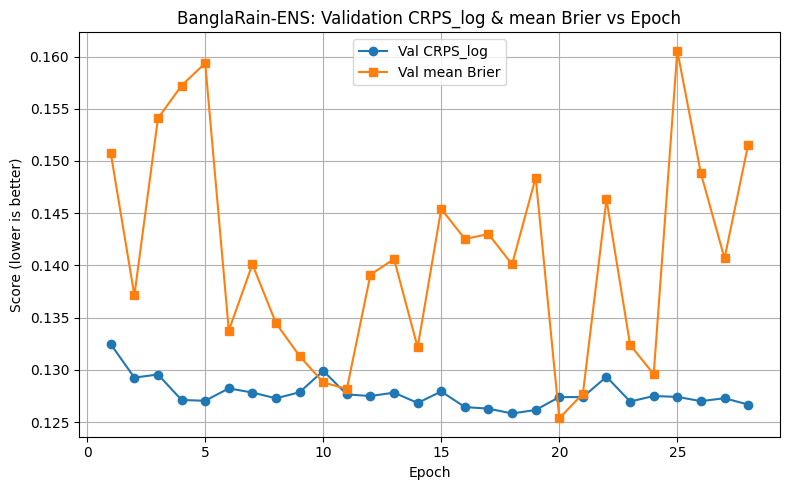

In [ ]:
# ============================================================
# BanglaRain-ENS — Standalone TESTING Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, and plot CRPS / Brier vs epoch.
#
# 👉 This file is SELF-CONTAINED:
#    - includes preprocessing functions
#    - dataset class
#    - model class
#    - evaluate()
#    - uses SAME model structure as tuning/training
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

import matplotlib.pyplot as plt


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    probs, y_true, mask are 1D numpy arrays.
    Returns PR-AUC, ROC-AUC, and CSI/POD/FAR at thresholds.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24 (FIXED indexing)
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n]=1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t  (T_in steps)
      Targets: t+1 .. t+H_out (H_out steps)

    Risk labels:
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h   (valid if >= peak_min_obs observed)
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24 (valid if all H_out observed)
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        # NOTE: this can warn if all-NaN; logic is still correct for labels+mask
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (SAME STRUCTURE AS TUNING/TRAINING)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Evaluation function
# ============================================================
# ============================================================
# 7) Evaluation function (Hybrid: Metrics + Saving)
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5), save_path="test_predictions.npz"):
    model.eval()

    # --- Metrics Accumulators ---
    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    # Streaming MAE/RMSE
    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    # --- Lists for Metrics Calculation ---
    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    # --- Lists for Saving to NPZ (Visualization) ---
    save_q_hat = []
    save_y_log = []
    save_flash_p = []
    save_flash_y = []

    # Station-wise error tracking for Spatial Map
    station_crps_sum = {}
    station_count_n = {}

    print(f"Evaluating and generating {save_path}...")

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        edge_index = edge_index.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        # 1. Standard Probabilistic Metrics
        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()
        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()
        nb += 1

        # 2. Deterministic Metrics (MAE/RMSE)
        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)
        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        # 3. Collect Data for Final Metrics (POD/CSI)
        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))
        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))
        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

        # 4. Collect Data for Saving (Case Study / Spatial Map)
        # Move to CPU numpy
        q_hat_np = q_hat.detach().cpu().numpy()
        y_log_np = y_log.detach().cpu().numpy()
        mask_np  = my.detach().cpu().numpy()

        save_q_hat.append(q_hat_np)
        save_y_log.append(y_log_np)
        save_flash_p.append(p_flash.detach().cpu().numpy())
        save_flash_y.append(flash.detach().cpu().numpy())

        # Accumulate Station-wise CRPS (for Spatial Map)
        # Average over horizons and quantiles
        for n_idx in range(N):
            valid = mask_np[:, :, n_idx] > 0.5
            if not valid.any(): continue

            # Simple CRPS calc for this station in this batch
            loss_batch = 0
            cnt_batch = 0
            for k_idx, q_val in enumerate(quantiles):
                e = y_log_np[:, :, n_idx] - q_hat_np[:, :, n_idx, k_idx]
                loss = np.maximum((q_val - 1.0) * e, q_val * e)
                loss = loss * valid
                loss_batch += loss.sum()
                cnt_batch += valid.sum()

            if n_idx not in station_crps_sum:
                station_crps_sum[n_idx] = 0.0
                station_count_n[n_idx] = 0
            station_crps_sum[n_idx] += (loss_batch * 2.0)
            station_count_n[n_idx] += cnt_batch

    # --- END LOOP ---

    # A. Save NPZ File
    full_q_hat = np.concatenate(save_q_hat, axis=0)
    full_y_log = np.concatenate(save_y_log, axis=0)
    full_flash_p = np.concatenate(save_flash_p, axis=0) # [Samples, Nodes]
    full_flash_y = np.concatenate(save_flash_y, axis=0) # [Samples, Nodes]

    # Finalize Spatial CRPS
    station_crps_final = []
    for n_idx in range(len(station_crps_sum)):
        if station_count_n.get(n_idx, 0) > 0:
            station_crps_final.append(station_crps_sum[n_idx] / station_count_n[n_idx])
        else:
            station_crps_final.append(np.nan)

    np.savez(save_path,
             q_hat=full_q_hat,
             y_log=full_y_log,
             flash_p=full_flash_p.flatten(),
             flash_y=full_flash_y.flatten(),
             station_crps=np.array(station_crps_final))
    print(f"Saved {save_path} successfully.")

    # B. Compile Final Scores
    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()
    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()
    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Reload final model, rebuild TEST set, evaluate, plot
# ============================================================

# Ensure this matches the EXACT path where your training script saved the model
FINAL_SAVE_DIR =  "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2"

CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 8.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

hp = ckpt["hparams"]            # dict of best hyperparameters
state_dict = ckpt["state_dict"] # model weights

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")

# ---- 8.2 Extract Frozen Train-Set Statistics (PREVENTS DATA LEAKAGE) ----
saved_mean = ckpt["scaler_mean"]
saved_std = ckpt["scaler_std"]
thr3h_saved = ckpt["thr3h"]
thrAcc24_saved = ckpt["thrAcc24"]

# ---- 8.3 Rebuild preprocessing + TEST dataset ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# --- APPLY FROZEN SCALER ---
X_flat = prep["X_raw"].reshape(T*N, prep["X_raw"].shape[-1])
scaler = NaNIgnoringStandardScaler()
# Manually inject the saved parameters to guarantee no validation/test leakage
scaler.mean_ = saved_mean
scaler.std_ = saved_std

X_scaled_flat = scaler.transform(X_flat)
X_scaled = X_scaled_flat.reshape(T, N, prep["X_raw"].shape[-1]).astype(np.float32)

# --- APPLY FROZEN THRESHOLDS ---
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))

# Build TEST dataset using the saved thresholds
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h_saved, thrAcc24_saved,  # Using the frozen thresholds!
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test,
                         batch_size=int(hp["batch_size"]),
                         shuffle=False)

print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 8.4 Rebuild model and load weights ----
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 8.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
        device=device,
    )

print("\n========== TEST METRICS ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

# Print MAE and RMSE
maes = test_scores["MAE_mm_by_lead"]
rmses = test_scores["RMSE_mm_by_lead"]
print(f"\n[Deterministic] Mean MAE:  {np.nanmean(maes):.4f} mm")
print(f"[Deterministic] Mean RMSE: {np.nanmean(rmses):.4f} mm")
print(f"(MAE per 3h step: {maes})")
print(f"(RMSE per 3h step: {rmses})")

# Print CSI, POD, FAR
target_thr = 0.5

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

def print_event_metrics(name, metrics, thr):
    print(f"\n[{name}] PR-AUC={metrics['pr_auc']:.4f}, ROC-AUC={metrics['roc_auc']:.4f}")
    if thr in metrics["by_thr"]:
        m = metrics["by_thr"][thr]
        print(f"  @Thr={thr}: CSI={m['CSI']:.4f}, POD={m['POD']:.4f}, FAR={m['FAR']:.4f}")
    else:
        print(f"  @Thr={thr}: Metrics not found")

print_event_metrics("Flash 3h", fm, target_thr)
print_event_metrics("Peak 24h", pm, target_thr)
print_event_metrics("Acc 24h",  am, target_thr)

# ---- 8.6 Plot learning curves from final_epoch_log.csv ----
log_df = pd.read_csv(LOG_PATH)
print("\nLoaded epoch log with {} rows.".format(len(log_df)))

log_df["mean_brier"] = log_df[["val_Brier_flash", "val_Brier_peak", "val_Brier_acc"]].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
plt.xlabel("Epoch")
plt.ylabel("Score (lower is better)")
plt.title("BanglaRain-ENS: Validation CRPS_log & mean Brier vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# **Training convergence and validation performance in log-space CRPS for the proposed BanglaRain-ENS model compared to ablation baselines**

Loaded w/o Missingness (Forward Fill): 30 epochs.
Loaded w/o Physics: 35 epochs.
Loaded w/o Regime: 19 epochs.
Loaded BanglaRain (k=3): 34 epochs.
Loaded BanglaRain (k=7): 28 epochs.

Figure saved to: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Ablation_Training_Curves.pdf


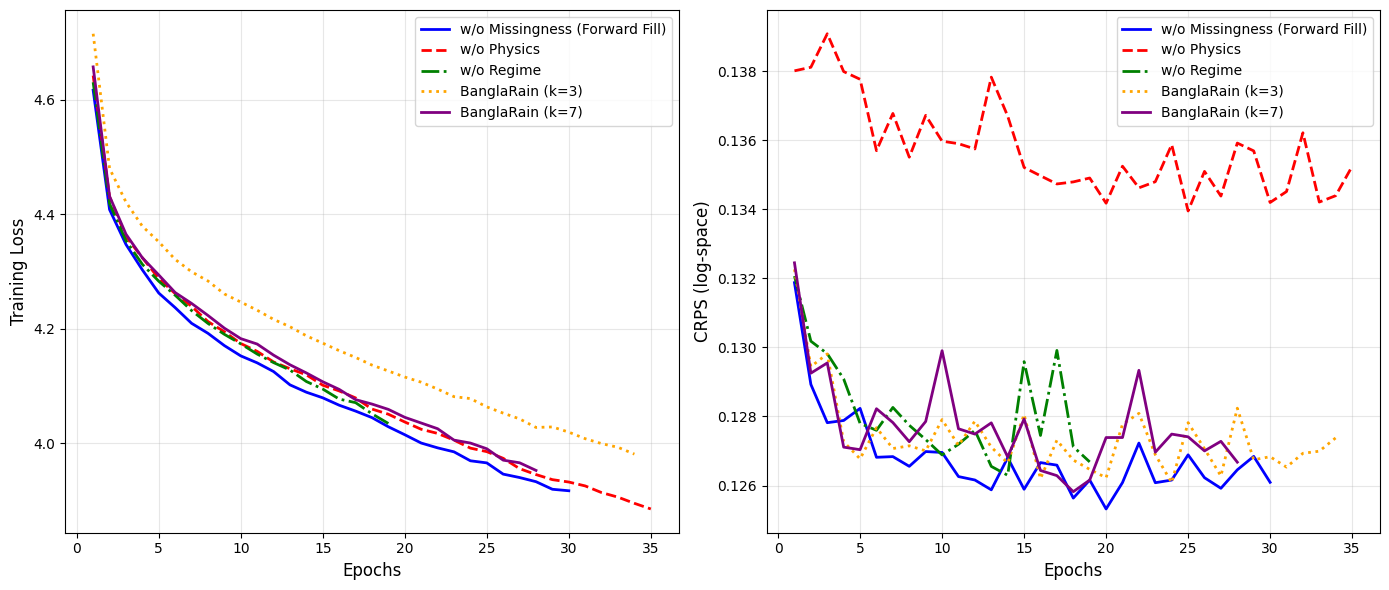

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. Configuration (UPDATE THESE PATHS)
# ==========================================
# Map the 'Label for Legend' -> 'Path to CSV file'
files = {
    "w/o Missingness (Forward Fill)":           "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_no_missing/v2/final_epoch_log.csv",
    "w/o Physics":               "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_no_phys/v2/final_epoch_log.csv",
    "w/o Regime":                "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_no_regime/v2/final_epoch_log.csv",
    "BanglaRain (k=3)": "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k3/v2/final_epoch_log.csv",
    "BanglaRain (k=7)": "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_epoch_log.csv",
}

# ==========================================
# 2. Setup Plot (2 Subplots: Train & Val)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['b', 'r', 'g', 'orange', 'purple']
linestyles = ['-', '--', '-.', ':', '-']

# ==========================================
# 3. Loop & Plot
# ==========================================
for i, (label, filepath) in enumerate(files.items()):
    if not os.path.exists(filepath):
        print(f"Warning: File not found: {filepath}")
        continue

    try:
        # Read CSV
        df = pd.read_csv(filepath)

        # --- Plot Training Loss ---
        ax1.plot(df['epoch'], df['train_loss'],
                 label=label,
                 color=colors[i % len(colors)],
                 linestyle=linestyles[i % len(linestyles)],
                 linewidth=2)

        # --- Plot Validation Metric (CRPS mm) ---
        # Note: We use val_CRPS_mm as it is the physical error metric
        ax2.plot(df['epoch'], df['val_CRPS_log'],
                 label=label,
                 color=colors[i % len(colors)],
                 linestyle=linestyles[i % len(linestyles)],
                 linewidth=2)

        print(f"Loaded {label}: {len(df)} epochs.")

    except Exception as e:
        print(f"Error reading {label}: {e}")

# ==========================================
# 4. Styling
# ==========================================
# Subplot 1: Training Loss
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Training Loss", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Subplot 2: Validation CRPS
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("CRPS (log-space)", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()

# Save
save_path = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Ablation_Training_Curves.pdf"
plt.savefig(save_path, dpi=300)
print(f"\nFigure saved to: {save_path}")
plt.show()

# **Training convergence and validation performance in log-space CRPS for the proposed BanglaRain-ENS model compared to Baselines**

Loaded QuantileLSTM: 16 epochs.
Loaded DeepAR: 34 epochs.
Loaded GraphOnly: 38 epochs.
Loaded TemporalOnly: 22 epochs.
Loaded BanglaRain (k=3): 34 epochs.
Loaded BanglaRain (k=7): 28 epochs.

Figure saved to: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Baseline_Training_Curves.pdf


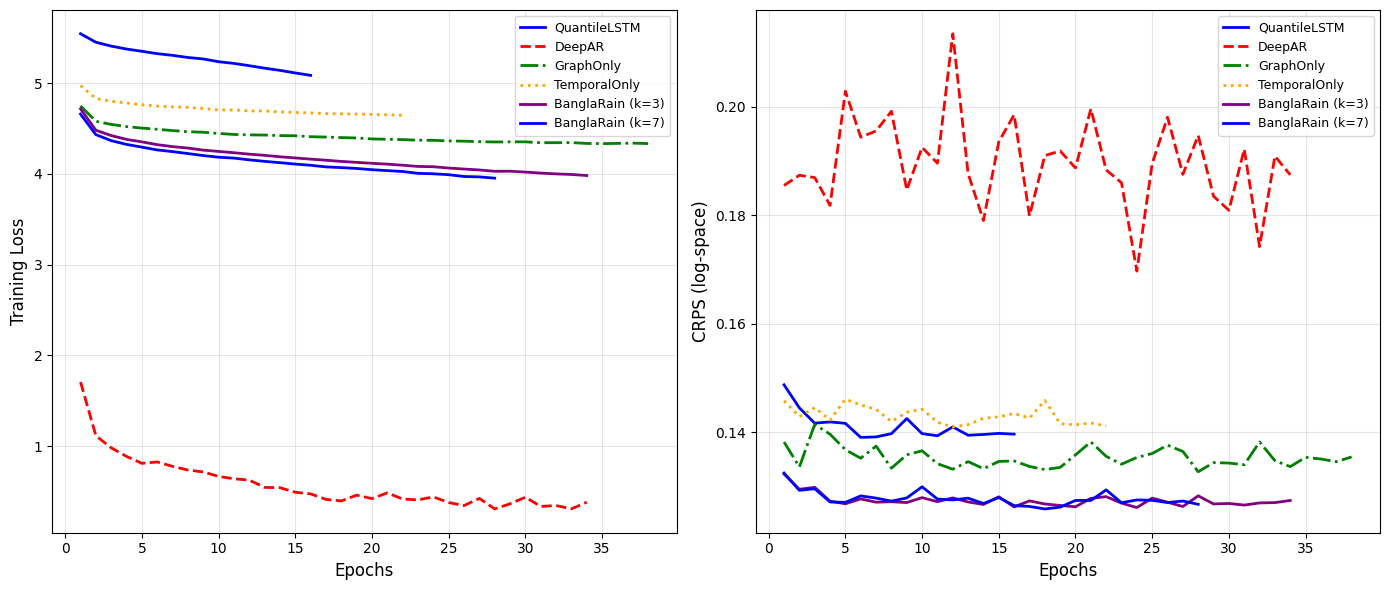

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. Configuration (UPDATE THESE PATHS)
# ==========================================
# Map the 'Label for Legend' -> 'Path to CSV file'
files = {
    "QuantileLSTM":"/content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/QuantileLSTM/Final_Run/v2/final_epoch_log.csv",
    "DeepAR": "/content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/DeepAR/Final_Run/v2/final_epoch_log.csv",
    "GraphOnly": "/content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/GraphOnly/Final_Run/v2/final_epoch_log.csv",
    "TemporalOnly":"/content/drive/MyDrive/Rainfall/Updated Research Data/Baselines/TemporalOnly/Final_Run/v2/final_epoch_log.csv",
    "BanglaRain (k=3)": "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k3/v2/final_epoch_log.csv",
    "BanglaRain (k=7)": "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_epoch_log.csv",
}

# ==========================================
# 2. Setup Plot (2 Subplots: Train & Val)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['b', 'r', 'g', 'orange', 'purple']
linestyles = ['-', '--', '-.', ':', '-']

# ==========================================
# 3. Loop & Plot
# ==========================================
for i, (label, filepath) in enumerate(files.items()):
    if not os.path.exists(filepath):
        print(f"Warning: File not found: {filepath}")
        continue

    try:
        # Read CSV
        df = pd.read_csv(filepath)

        # --- Plot Training Loss ---
        ax1.plot(df['epoch'], df['train_loss'],
                 label=label,
                 color=colors[i % len(colors)],
                 linestyle=linestyles[i % len(linestyles)],
                 linewidth=2)

        # --- Plot Validation Metric (CRPS mm) ---
        # Note: We use val_CRPS_mm as it is the physical error metric
        ax2.plot(df['epoch'], df['val_CRPS_log'],
                 label=label,
                 color=colors[i % len(colors)],
                 linestyle=linestyles[i % len(linestyles)],
                 linewidth=2)

        print(f"Loaded {label}: {len(df)} epochs.")

    except Exception as e:
        print(f"Error reading {label}: {e}")

# ==========================================
# 4. Styling
# ==========================================
# Subplot 1: Training Loss
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Training Loss", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.legend(loc='upper right', fontsize=9)

# Subplot 2: Validation CRPS
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("CRPS (log-space)", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()

# Save
save_path = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Baseline_Training_Curves.pdf"
plt.savefig(save_path, dpi=300)
print(f"\nFigure saved to: {save_path}")
plt.show()

##

# **Performance Analysis (Year 2017 & 2022)**

In [ ]:
# ============================================================
# BanglaRain-ENS — EXTREME YEAR ANALYSIS (2017 & 2022)
# Reloads final Full Model, isolates temporal subsets for
# extreme years, and prints the comparison table.
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1) Utilities & Preprocessing
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_knn_graph(stations_df, k=4):
    lat, lon = stations_df["Latitude"].values, stations_df["Longitude"].values
    node_idx, n = stations_df["node_index"].values, len(stations_df)
    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n): dist_mat[i] = haversine(lat[i], lon[i], lat, lon)
    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.update([(u, v), (v, u)])
    return np.array(list(edge_list)).T

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8): self.eps = eps
    def fit(self, X):
        self.mean_, self.std_ = np.nanmean(X, axis=0), np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self
    def transform(self, X): return (X - self.mean_) / self.std_

def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None: return (loss * mask).sum() / mask.sum().clamp_min(1.0)
    return loss.mean()

def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = [pinball_loss(y_hat[..., k], y_true, q, mask=mask) for k, q in enumerate(quantiles)]
    return 2.0 * torch.stack(losses).mean()

def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None: return (loss * mask).sum() / mask.sum().clamp_min(1.0)
    return loss.mean()

def safe_div(a, b, eps=1e-12): return a / (b + eps)

def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    valid = mask > 0.5
    if valid.sum() < 50: return {"n_valid": int(valid.sum()), "pr_auc": np.nan, "roc_auc": np.nan, "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds}}
    p, y = probs[valid], y_true[valid]
    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try: roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except: roc_auc = np.nan
    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP, FP, FN = ((yhat == 1) & (y == 1)).sum(), ((yhat == 1) & (y == 0)).sum(), ((yhat == 0) & (y == 1)).sum()
        by_thr[thr] = {"POD": float(safe_div(TP, TP + FN)), "FAR": float(safe_div(FP, TP + FP)), "CSI": float(safe_div(TP, TP + FP + FN))}
    return {"n_valid": int(valid.sum()), "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan, "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan, "by_thr": by_thr}

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)
    dr_rad = np.deg2rad(df["DR"].astype(np.float32).to_numpy())
    df["DR_sin"], df["DR_cos"] = np.sin(dr_rad), np.cos(dr_rad)
    stations = df[["StationID", "StationName", "Latitude", "Longitude"]].drop_duplicates().sort_values("StationID").reset_index(drop=True)
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N, times = len(stations), np.sort(df["Datetime"].unique())
    T = len(times)
    full_index = pd.MultiIndex.from_product([times, stations["StationID"].values], names=["Datetime", "StationID"])
    meteo_cols = ["DewPointTemperature", "StationLevelPressure", "SP", "Humidity", "Rainfall", "DR_sin", "DR_cos"]
    X_raw = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index().reindex(full_index).values.reshape(T, N, len(meteo_cols)).astype(np.float32)
    M_in = (~np.isnan(X_raw)).astype(np.float32)
    rain_idx = meteo_cols.index("Rainfall")
    Y_rain, M_y = X_raw[..., rain_idx], M_in[..., rain_idx]
    dt_index = pd.DatetimeIndex(times)
    hour, month = dt_index.hour.astype(np.float32), dt_index.month.astype(np.float32)
    time_feats = np.repeat(np.stack([np.sin(2*np.pi*(hour/24.0)), np.cos(2*np.pi*(hour/24.0)), np.sin(2*np.pi*((month-1)/12.0)), np.cos(2*np.pi*((month-1)/12.0))], axis=-1).astype(np.float32)[:, None, :], N, axis=1)
    season_by_time = df.groupby("Datetime")["Season"].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]).reindex(times).astype(str).values
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    return {"stations": stations, "stationid_to_node": stationid_to_node, "node_to_stationid": node_to_stationid, "times": times, "X_raw": X_raw, "M_in": M_in, "Y_rain": Y_rain, "M_y": M_y, "meteo_cols": meteo_cols, "time_feats": time_feats, "season_ids": np.array([season_to_id[s] for s in season_by_time], dtype=np.int64), "unique_seasons": unique_seasons, "season_to_id": season_to_id}

def make_splits(T, train_frac=0.7, val_frac=0.15): return int(T * train_frac), int(T * (train_frac + val_frac))

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train, M_train, N = Y[:train_end], M[:train_end], Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)
    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0
    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        thr[j] = np.nanpercentile(vals, q*100) if len(vals) >= 100 else global_fallback
    return thr

def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc, Mask = np.full((T, N), np.nan, dtype=np.float32), np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window, wmask = Y_rain[t+1:t+1+H_out], M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok], Acc[t, ok] = 1.0, window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 2) Dataset & Model
# ============================================================
class BanglaRainDataset(Dataset):
    def __init__(self, X_scaled, M_in, time_feats, Y_rain, M_y, Acc24, MaskAcc24, season_ids, thr3h, thrAcc24, t_start, t_end, T_in=16, H_out=8, peak_min_obs=None):
        self.X_scaled, self.M_in, self.time_feats = X_scaled, M_in, time_feats
        self.Y_rain, self.M_y, self.Acc24, self.MaskAcc24 = Y_rain, M_y, Acc24, MaskAcc24
        self.season_ids, self.thr3h, self.thrAcc24 = season_ids, thr3h, thrAcc24
        self.T_in, self.H_out = T_in, H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)
        self.indices = list(range(t_start + (T_in - 1), t_end - H_out))

    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        t = self.indices[idx]
        x_all = np.concatenate([np.nan_to_num(self.X_scaled[t-self.T_in+1:t+1], nan=0.0).astype(np.float32), self.M_in[t-self.T_in+1:t+1].astype(np.float32), self.time_feats[t-self.T_in+1:t+1]], axis=-1)
        y_win, m_win = self.Y_rain[t+1:t+1+self.H_out], self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y_win, nan=0.0)).astype(np.float32)
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((self.Y_rain[t+1] >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((self.Acc24[t] >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)
        return torch.from_numpy(x_all), torch.tensor(int(self.season_ids[t]), dtype=torch.long), torch.from_numpy(y_log), torch.from_numpy(m_win), torch.from_numpy(flash), torch.from_numpy(m_next), torch.from_numpy(peak24), torch.from_numpy(mpeak), torch.from_numpy(acc24), torch.from_numpy(macc)

class BanglaRainENS(nn.Module):
    def __init__(self, num_stations, in_features, T_in, H_out, num_seasons, quantiles=(0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95), d_model=96, n_heads=4, num_temporal_layers=2, num_gat_layers=2, gat_heads=2, dropout=0.1):
        super().__init__()
        self.N, self.T_in, self.H_out, self.quantiles, self.K, self.d_model = num_stations, T_in, H_out, list(quantiles), len(quantiles), d_model
        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)
        self.temporal_encoder = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model, dropout=dropout, batch_first=True), num_layers=num_temporal_layers)
        self.regime_embedding = nn.Embedding(num_seasons, d_model)
        self.gat_layers = nn.ModuleList([GATConv(in_channels=d_model, out_channels=d_model, heads=gat_heads, concat=False, dropout=dropout) for _ in range(num_gat_layers)])
        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head, self.peak_head, self.acc_head = nn.Linear(d_model, 1), nn.Linear(d_model, 1), nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        B, T, N, F_in = x.shape
        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]
        h = self.temporal_encoder(h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model))
        h_last = h[:, -1, :].reshape(B, N, self.d_model)
        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)
        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = F.relu(gat(g, edge_batch) + g_in)
        g = g.reshape(B, N, self.d_model)
        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        return q, self.flash_head(g).squeeze(-1), self.peak_head(g).squeeze(-1), self.acc_head(g).squeeze(-1)

# ============================================================
# 3) Evaluation Function (Updated to skip NPZ save if None)
# ============================================================
@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5), save_path=None):
    model.eval()
    total_crps_log = total_crps_mm = total_brier_flash = total_brier_peak = total_brier_acc = nb = 0
    k50 = int(np.argmin(np.abs(np.array(list(quantiles), dtype=np.float32) - 0.5)))
    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list, peak_y_list, peak_m_list = [], [], []
    acc_p_list, acc_y_list, acc_m_list = [], [], []
    H_out, sum_abs, sum_sq, count = None, None, None, None

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x, reg, edge_index_dev, y_log, my = x.to(device), reg.to(device), edge_index.to(device), y_log.to(device), my.to(device)
        flash, mflash, peak, mpeak, acc, macc = flash.to(device), mflash.to(device), peak.to(device), mpeak.to(device), acc.to(device), macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index_dev)
        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()
        q_mm, y_mm = torch.expm1(q_hat).clamp_min(0.0), torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash, p_peak, p_acc = torch.sigmoid(flash_logits), torch.sigmoid(peak_logits), torch.sigmoid(acc_logits)
        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak += brier_score(p_peak, peak, mask=mpeak).item()
        total_brier_acc += brier_score(p_acc, acc, mask=macc).item()
        nb += 1

        q50_log, q50_mm = q_hat[..., k50], torch.expm1(q_hat[..., k50]).clamp_min(0.0)
        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs, sum_sq, count = torch.zeros(H_out, device="cpu"), torch.zeros(H_out, device="cpu"), torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h] += (err**2).sum()
                count[h] += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1)); flash_y_list.append(flash.detach().cpu().reshape(-1)); flash_m_list.append(mflash.detach().cpu().reshape(-1))
        peak_p_list.append(p_peak.detach().cpu().reshape(-1)); peak_y_list.append(peak.detach().cpu().reshape(-1)); peak_m_list.append(mpeak.detach().cpu().reshape(-1))
        acc_p_list.append(p_acc.detach().cpu().reshape(-1)); acc_y_list.append(acc.detach().cpu().reshape(-1)); acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1), "CRPS_mm": total_crps_mm / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1), "Brier_peak": total_brier_peak / max(nb, 1), "Brier_acc": total_brier_acc / max(nb, 1),
        "Flash_metrics": event_metrics_binary(torch.cat(flash_p_list).numpy(), torch.cat(flash_y_list).numpy(), torch.cat(flash_m_list).numpy(), thresholds=thresholds),
        "Peak24_metrics": event_metrics_binary(torch.cat(peak_p_list).numpy(), torch.cat(peak_y_list).numpy(), torch.cat(peak_m_list).numpy(), thresholds=thresholds),
        "Acc24_metrics": event_metrics_binary(torch.cat(acc_p_list).numpy(), torch.cat(acc_y_list).numpy(), torch.cat(acc_m_list).numpy(), thresholds=thresholds)
    }
    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1: maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else: maes.append(float((sum_abs[h] / count[h]).item())); rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item())); counts.append(int(count[h].item()))
    out.update({"MAE_mm_by_lead": maes, "RMSE_mm_by_lead": rmses, "n_valid_by_lead": counts})
    return out


# ============================================================
# 4) Main Execution & Extreme Year Logic
# ============================================================

# Ensure this points to your specific FULL MODEL path
FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2"
CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")

print("\nLoading Checkpoint:", CKPT_PATH)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
hp, state_dict = ckpt["hparams"], ckpt["state_dict"]
saved_mean, saved_std, thr3h_saved, thrAcc24_saved = ckpt["scaler_mean"], ckpt["scaler_std"], ckpt["thr3h"], ckpt["thrAcc24"]

# >>> IMPORTANT: Make sure df_rain is loaded before this point <<<
# df_rain = pd.read_csv("path_to_df_rain.csv")

prep = prepare_full_grid(df_rain)
stations, times = prep["stations"], prep["times"]
N, T = len(stations), len(times)
edge_index = torch.tensor(build_knn_graph(stations, k=int(hp["k_nn"])), dtype=torch.long).to(device)

_, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

X_flat = prep["X_raw"].reshape(T*N, prep["X_raw"].shape[-1])
scaler = NaNIgnoringStandardScaler()
scaler.mean_, scaler.std_ = saved_mean, saved_std
X_scaled = scaler.transform(X_flat).reshape(T, N, prep["X_raw"].shape[-1]).astype(np.float32)
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))

# -------------------------------------
# Rebuild Model
# -------------------------------------
# Infer input dimension dynamically based on Dataset slice
dummy_ds = BanglaRainDataset(X_scaled, prep["M_in"], prep["time_feats"], prep["Y_rain"], prep["M_y"], Acc24, MaskAcc24, prep["season_ids"], thr3h_saved, thrAcc24_saved, t_start=val_end, t_end=T, T_in=int(hp["T_in"]), H_out=int(hp["H_out"]))
F_in = dummy_ds[0][0].shape[-1]

model = BanglaRainENS(num_stations=N, in_features=F_in, T_in=int(hp["T_in"]), H_out=int(hp["H_out"]), num_seasons=len(prep["unique_seasons"]), quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))), d_model=int(hp["d_model"]), n_heads=int(hp["n_heads"]), num_temporal_layers=int(hp["num_temporal_layers"]), num_gat_layers=int(hp["num_gat_layers"]), gat_heads=int(hp["gat_heads"]), dropout=float(hp["dropout"])).to(device)
model.load_state_dict(state_dict)
model.eval()

# -------------------------------------
# Overall Test Evaluation
# -------------------------------------
test_loader = DataLoader(dummy_ds, batch_size=int(hp["batch_size"]), shuffle=False)
print(f"\nEvaluating Overall Test Set (Samples: {len(dummy_ds)})...")
test_scores = evaluate(model, test_loader, edge_index, tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))), device, save_path=None)

# -------------------------------------
# EXTREME YEAR EVALUATION (2017 & 2022)
# -------------------------------------
print("\n========== ISOLATED PERFORMANCE FOR EXTREME YEARS (2017 & 2022) ==========")

years = pd.DatetimeIndex(times).year
idx_2017 = np.where(years == 2017)[0]
idx_2022 = np.where(years == 2022)[0]

if len(idx_2017) > 0 and len(idx_2022) > 0:
    start_2017, end_2017 = idx_2017[0], idx_2017[-1] + 1
    start_2022, end_2022 = idx_2022[0], idx_2022[-1] + 1

    # Ensure they don't crash if the year is too short for T_in/H_out
    try:
        ds_2017 = BanglaRainDataset(X_scaled, prep["M_in"], prep["time_feats"], prep["Y_rain"], prep["M_y"], Acc24, MaskAcc24, prep["season_ids"], thr3h_saved, thrAcc24_saved, t_start=start_2017, t_end=end_2017, T_in=int(hp["T_in"]), H_out=int(hp["H_out"]))
        loader_2017 = DataLoader(ds_2017, batch_size=int(hp["batch_size"]), shuffle=False)
        print(f"Evaluating Year 2017 (Samples: {len(ds_2017)})...")
        scores_2017 = evaluate(model, loader_2017, edge_index, tuple(hp.get("quantiles")), device, save_path=None)
    except Exception as e:
        print(f"Error evaluating 2017: {e}")
        scores_2017 = None

    try:
        ds_2022 = BanglaRainDataset(X_scaled, prep["M_in"], prep["time_feats"], prep["Y_rain"], prep["M_y"], Acc24, MaskAcc24, prep["season_ids"], thr3h_saved, thrAcc24_saved, t_start=start_2022, t_end=end_2022, T_in=int(hp["T_in"]), H_out=int(hp["H_out"]))
        loader_2022 = DataLoader(ds_2022, batch_size=int(hp["batch_size"]), shuffle=False)
        print(f"Evaluating Year 2022 (Samples: {len(ds_2022)})...")
        scores_2022 = evaluate(model, loader_2022, edge_index, tuple(hp.get("quantiles")), device, save_path=None)
    except Exception as e:
        print(f"Error evaluating 2022: {e}")
        scores_2022 = None

    # Print Summary Table
    def get_csi(scores, event="Peak24_metrics", thr=0.5):
        if scores is None: return np.nan
        try: return scores[event]["by_thr"][thr]["CSI"]
        except: return np.nan

    print("\n" + "="*75)
    print(f"{'Metric':<20} | {'Overall Test Set':<15} | {'2017 (Extreme)':<15} | {'2022 (Extreme)':<15}")
    print("-" * 75)

    c17 = f"{scores_2017['CRPS_log']:<15.4f}" if scores_2017 else "N/A"
    c22 = f"{scores_2022['CRPS_log']:<15.4f}" if scores_2022 else "N/A"
    print(f"{'CRPS_log':<20} | {test_scores['CRPS_log']:<15.4f} | {c17} | {c22}")

    cm17 = f"{scores_2017['CRPS_mm']:<15.4f}" if scores_2017 else "N/A"
    cm22 = f"{scores_2022['CRPS_mm']:<15.4f}" if scores_2022 else "N/A"
    print(f"{'CRPS_mm':<20} | {test_scores['CRPS_mm']:<15.4f} | {cm17} | {cm22}")

    mae17 = f"{np.nanmean(scores_2017['MAE_mm_by_lead']):<15.4f}" if scores_2017 else "N/A"
    mae22 = f"{np.nanmean(scores_2022['MAE_mm_by_lead']):<15.4f}" if scores_2022 else "N/A"
    print(f"{'MAE (mm)':<20} | {np.nanmean(test_scores['MAE_mm_by_lead']):<15.4f} | {mae17} | {mae22}")

    bp17 = f"{scores_2017['Brier_peak']:<15.4f}" if scores_2017 else "N/A"
    bp22 = f"{scores_2022['Brier_peak']:<15.4f}" if scores_2022 else "N/A"
    print(f"{'Brier Peak 24h':<20} | {test_scores['Brier_peak']:<15.4f} | {bp17} | {bp22}")

    csi_overall = get_csi(test_scores)
    csi_17 = get_csi(scores_2017)
    csi_22 = get_csi(scores_2022)
    print(f"{'Peak CSI (@0.5)':<20} | {csi_overall:<15.4f} | {csi_17:<15.4f} | {csi_22:<15.4f}")
    print("="*75)

else:
    print("\nWarning: Years 2017 and/or 2022 not found in the dataset time range.")

Using device: cpu

Loading Checkpoint: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_best_model.pt

Evaluating Overall Test Set (Samples: 9173)...


/tmp/ipykernel_2133/538414399.py:170: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)



========== ISOLATED PERFORMANCE FOR EXTREME YEARS (2017 & 2022) ==========
Evaluating Year 2017 (Samples: 2889)...


/tmp/ipykernel_2133/538414399.py:170: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)


Evaluating Year 2022 (Samples: 2889)...


/tmp/ipykernel_2133/538414399.py:170: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)



Metric               | Overall Test Set | 2017 (Extreme)  | 2022 (Extreme) 
---------------------------------------------------------------------------
CRPS_log             | 0.1068          | 0.1381          | 0.1056         
CRPS_mm              | 0.5726          | 0.8202          | 0.5573         
MAE (mm)             | 0.6665          | 1.0084          | 0.6332         
Brier Peak 24h       | 0.1345          | 0.1444          | 0.1534         
Peak CSI (@0.5)      | 0.4211          | 0.4862          | 0.3793         


In [ ]:
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2074299,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 09:00:00,2023,12,31,9,Winter,14.0,NaN,NaN,NaN,50.2,0.0
2074300,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 12:00:00,2023,12,31,12,Winter,15.7,NaN,NaN,NaN,71.5,0.0
2074301,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 15:00:00,2023,12,31,15,Winter,15.6,NaN,NaN,NaN,78.4,0.0
2074302,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-12-31 18:00:00,2023,12,31,18,Winter,14.8,NaN,NaN,NaN,84.2,0.0


In [ ]:
df_rain['Secondary_Region'].unique()

array(['Coastal', 'Riverine', 'Inland'], dtype=object)

# **REGIONAL EVALUATION (Inland, Coastal, Riverine)**

In [ ]:
# ============================================================
# 10) REGIONAL EVALUATION (Using 'Secondary_Region' column)
# ============================================================
print("\n========== REGIONAL PERFORMANCE ANALYSIS ==========")

# 1. Map node indices directly from your dataframe's Secondary_Region column
# Extract unique mapping of StationID to Region
region_mapping = df_rain[['StationID', 'Secondary_Region']].drop_duplicates()

# Merge this mapping with prep["stations"] to link the string regions to the integer node_indices
stations_with_regions = prep["stations"].merge(region_mapping, on="StationID", how="left")

# Extract node indices for each region dynamically
regions = {
    "Coastal": stations_with_regions[stations_with_regions['Secondary_Region'] == 'Coastal']['node_index'].tolist(),
    "Inland": stations_with_regions[stations_with_regions['Secondary_Region'] == 'Inland']['node_index'].tolist(),
    "Riverine": stations_with_regions[stations_with_regions['Secondary_Region'] == 'Riverine']['node_index'].tolist()
}

# 2. Custom DataLoader wrapper to mask out non-regional stations
class RegionalLoader:
    def __init__(self, loader, valid_nodes, total_N):
        self.loader = loader
        # Create a binary spatial mask (1 for valid region, 0 for hidden)
        self.spatial_mask_1d = torch.zeros(total_N, dtype=torch.float32)
        if len(valid_nodes) > 0:
            self.spatial_mask_1d[valid_nodes] = 1.0

        self.spatial_mask_2d = self.spatial_mask_1d.unsqueeze(0)              # [1, N]
        self.spatial_mask_3d = self.spatial_mask_1d.unsqueeze(0).unsqueeze(0) # [1, 1, N]

    def __iter__(self):
        for x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc in self.loader:
            # Multiply masks by the spatial mask to hide non-regional stations
            my_mod = my * self.spatial_mask_3d
            mflash_mod = mflash * self.spatial_mask_2d
            mpeak_mod = mpeak * self.spatial_mask_2d
            macc_mod = macc * self.spatial_mask_2d
            yield (x, reg, y_log, my_mod, flash, mflash_mod, peak, mpeak_mod, acc, macc_mod)

    def __len__(self):
        return len(self.loader)

# 3. Evaluate each region
regional_scores = {}
import os

for region_name, node_indices in regions.items():
    if len(node_indices) == 0:
        print(f"Warning: No stations found for {region_name} in the Secondary_Region column.")
        continue

    print(f"Evaluating {region_name} Region ({len(node_indices)} stations)...")
    reg_loader = RegionalLoader(test_loader, node_indices, N)

    # Evaluate (outputting to devnull to avoid cluttering your drive with regional NPZ files)
    scores = evaluate(
        model, reg_loader, edge_index,
        quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
        device=device, save_path=os.devnull
    )
    regional_scores[region_name] = scores

# 4. Print Final Summary Table
if regional_scores:
    print("\n" + "="*85)
    print(f"{'Metric':<20} | {'Overall Test Set':<15} | {'Coastal':<12} | {'Inland':<12} | {'Riverine':<12}")
    print("-" * 85)

    def safe_fmt(scores_dict, region, metric, is_mae=False):
        if region not in scores_dict: return "N/A"
        if is_mae: return f"{np.nanmean(scores_dict[region][metric]):.4f}"
        return f"{scores_dict[region][metric]:.4f}"

    def safe_csi(scores_dict, region, event="Peak24_metrics", thr=0.5):
        if region not in scores_dict: return "N/A"
        try: return f"{scores_dict[region][event]['by_thr'][thr]['CSI']:.4f}"
        except: return "N/A"

    print(f"{'CRPS_log':<20} | {test_scores['CRPS_log']:<15.4f} | {safe_fmt(regional_scores, 'Coastal', 'CRPS_log')} | {safe_fmt(regional_scores, 'Inland', 'CRPS_log')} | {safe_fmt(regional_scores, 'Riverine', 'CRPS_log')}")
    print(f"{'CRPS_mm':<20} | {test_scores['CRPS_mm']:<15.4f} | {safe_fmt(regional_scores, 'Coastal', 'CRPS_mm')} | {safe_fmt(regional_scores, 'Inland', 'CRPS_mm')} | {safe_fmt(regional_scores, 'Riverine', 'CRPS_mm')}")
    print(f"{'MAE (mm)':<20} | {np.nanmean(test_scores['MAE_mm_by_lead']):<15.4f} | {safe_fmt(regional_scores, 'Coastal', 'MAE_mm_by_lead', True)} | {safe_fmt(regional_scores, 'Inland', 'MAE_mm_by_lead', True)} | {safe_fmt(regional_scores, 'Riverine', 'MAE_mm_by_lead', True)}")
    print(f"{'Brier Peak 24h':<20} | {test_scores['Brier_peak']:<15.4f} | {safe_fmt(regional_scores, 'Coastal', 'Brier_peak')} | {safe_fmt(regional_scores, 'Inland', 'Brier_peak')} | {safe_fmt(regional_scores, 'Riverine', 'Brier_peak')}")

    csi_overall = safe_csi({'Overall': test_scores}, 'Overall')
    print(f"{'Peak CSI (@0.5)':<20} | {csi_overall:<15} | {safe_csi(regional_scores, 'Coastal'):<12} | {safe_csi(regional_scores, 'Inland'):<12} | {safe_csi(regional_scores, 'Riverine'):<12}")
    print("="*85)


========== REGIONAL PERFORMANCE ANALYSIS ==========
Evaluating Coastal Region (13 stations)...


/tmp/ipykernel_2133/538414399.py:170: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)


Evaluating Inland Region (16 stations)...


/tmp/ipykernel_2133/538414399.py:170: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)


Evaluating Riverine Region (5 stations)...


/tmp/ipykernel_2133/538414399.py:170: RuntimeWarning: All-NaN slice encountered
  peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)



Metric               | Overall Test Set | Coastal      | Inland       | Riverine    
-------------------------------------------------------------------------------------
CRPS_log             | 0.1068          | 0.1155 | 0.1029 | 0.0965
CRPS_mm              | 0.5726          | 0.6252 | 0.5560 | 0.4888
MAE (mm)             | 0.6665          | 0.7594 | 0.6248 | 0.5570
Brier Peak 24h       | 0.1345          | 0.1252 | 0.1429 | 0.1321
Peak CSI (@0.5)      | 0.4211          | 0.4114       | 0.4223       | 0.4397      


# **Extreme Event Case Studies**

In [ ]:
df_rain['StationName'].unique()

array(['Ambagan(Ctg.)', 'Barishal', 'Bhola', 'Bogura', 'Chandpur',
       'Chuadanga', "Cox'sBazar", 'Cumilla', 'Dhaka', 'Dinajpur',
       'Faridpur', 'Feni', 'Hatiya', 'Ishurdi', 'Jessore', 'Khepupara',
       'Khulna', 'Kutubdia', 'Madaripur', 'Maijdee_court', 'Mongla',
       'Mymensingh', 'Patuakhali', 'Rajshahi', 'Rangamati', 'Rangpur',
       'Saidpur', 'Sandwip', 'Satkhira', 'Sitakunda', 'Srimangal',
       'Sylhet', 'Tangail', 'Teknaf'], dtype=object)

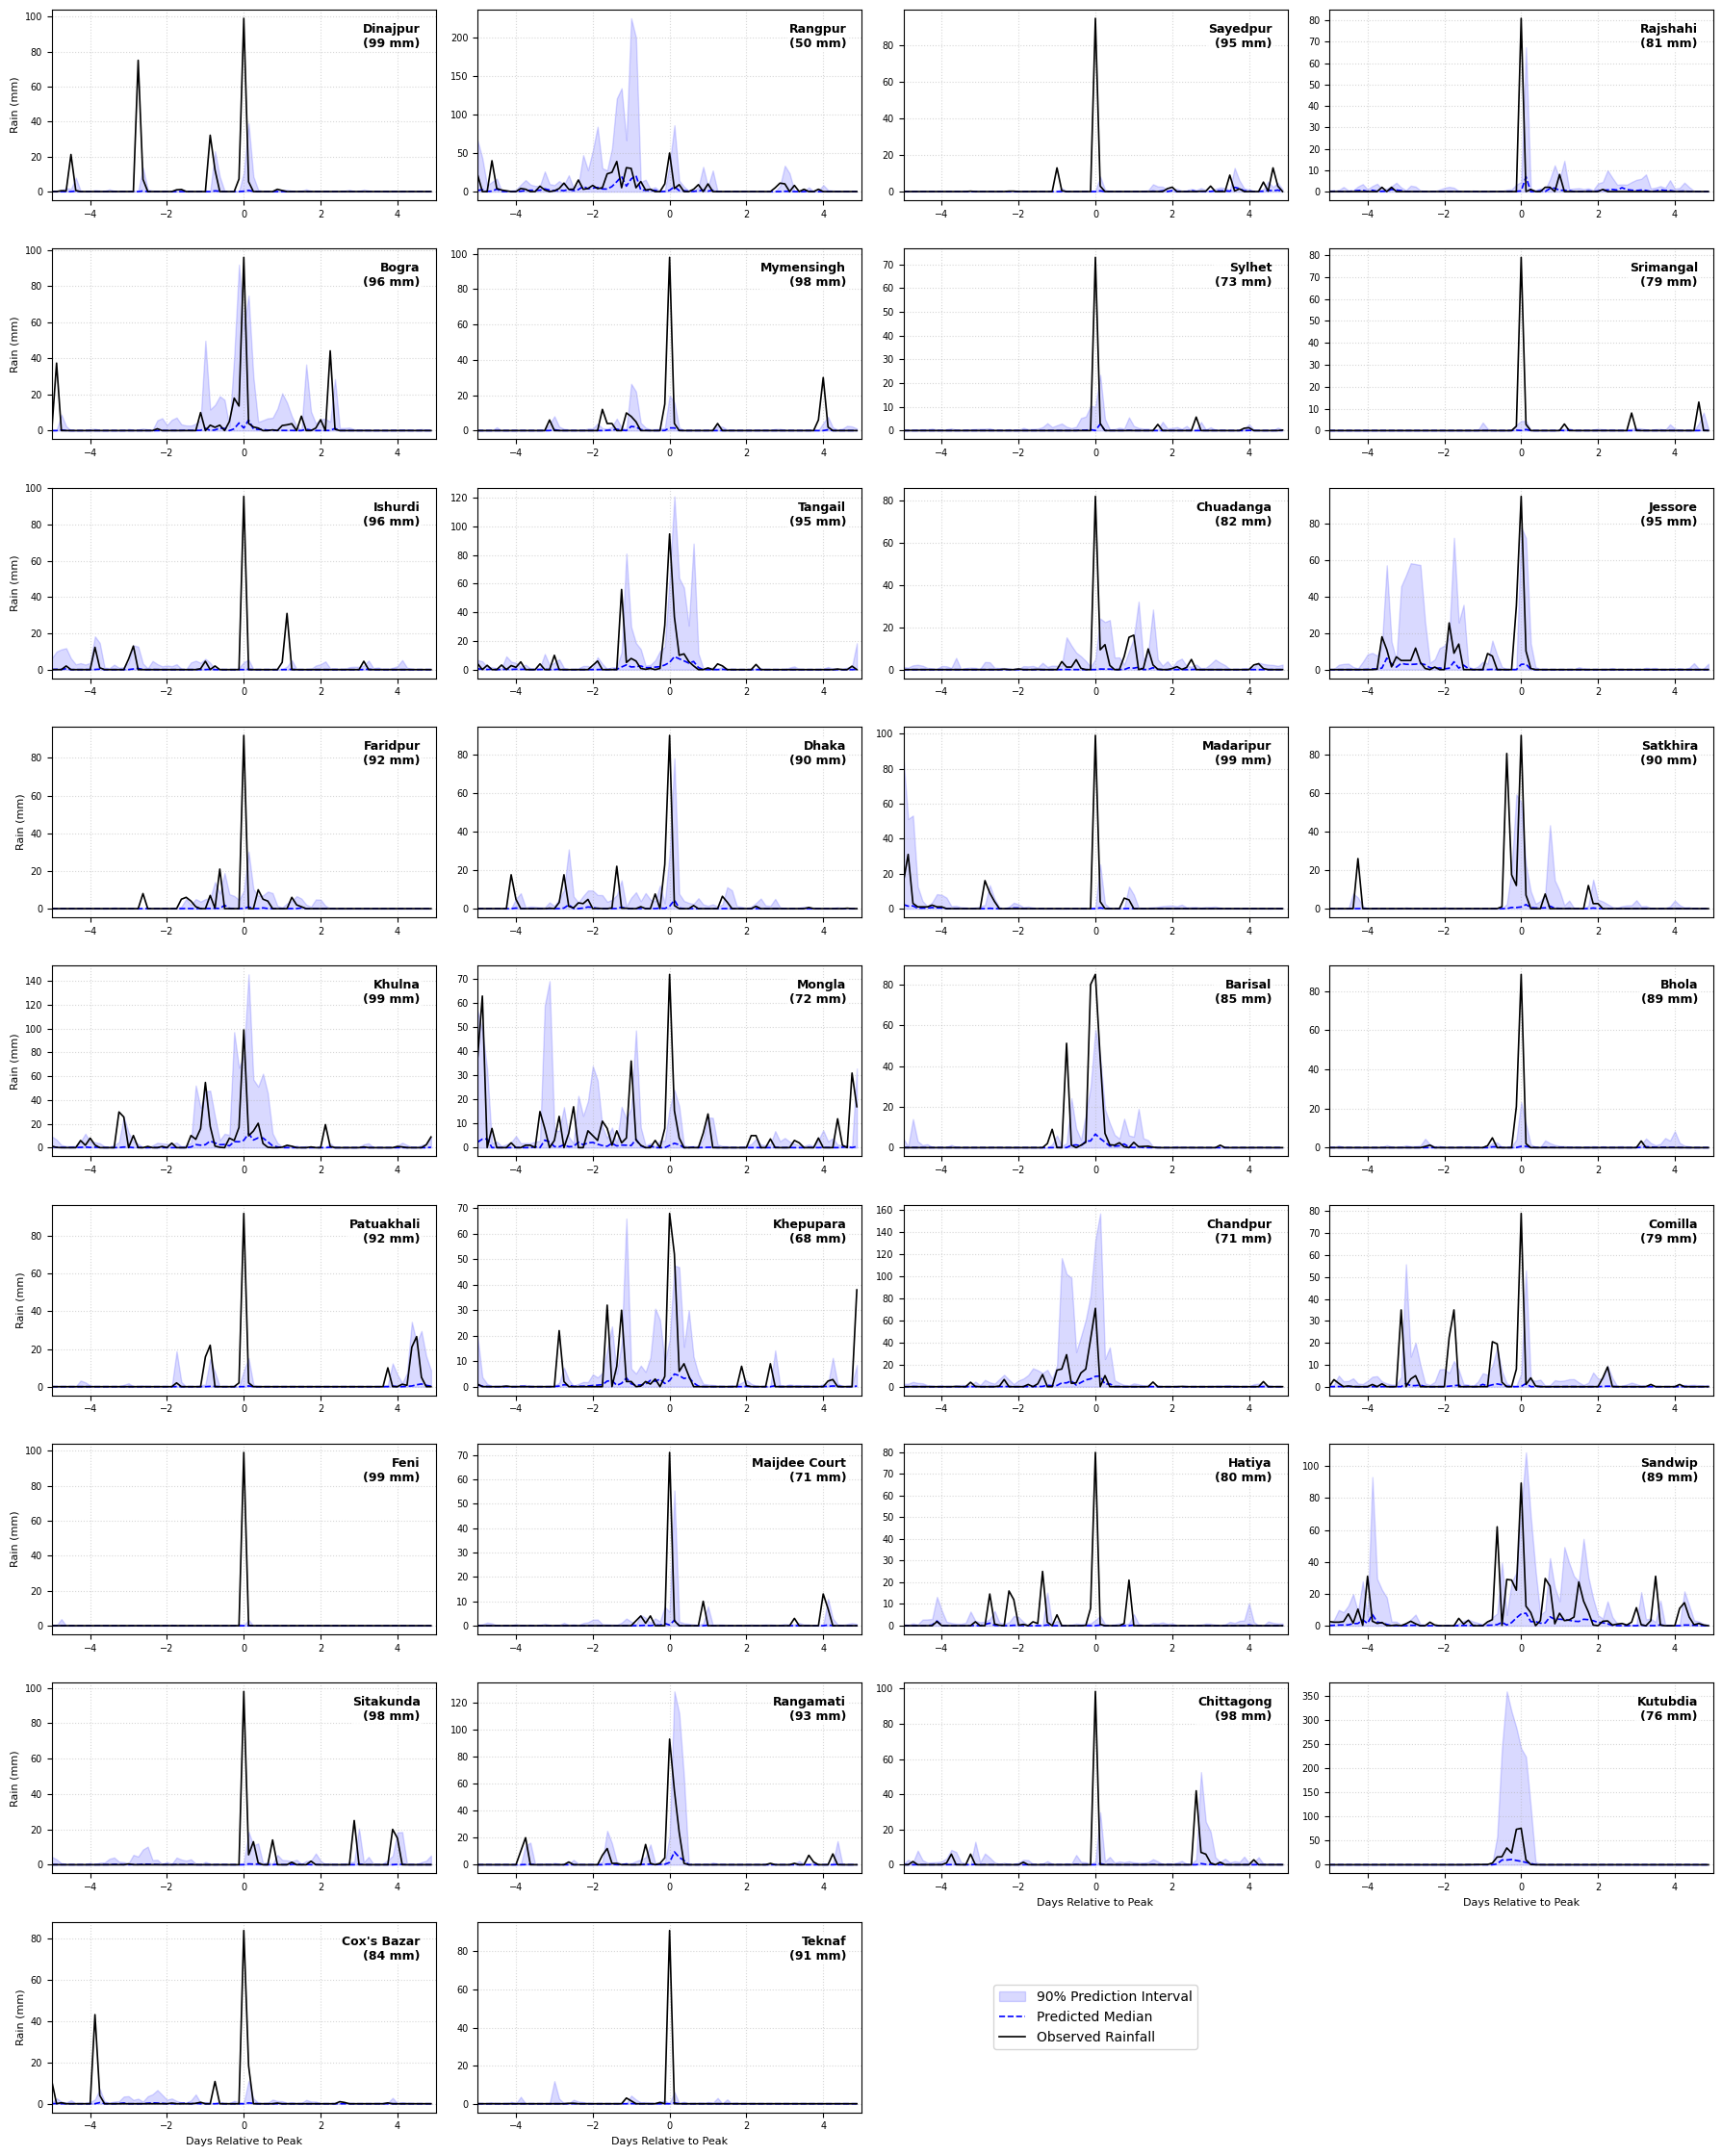

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
FILE_PATH = "test_predictions.npz" # Ensure this points to your actual NPZ file

STATION_NAMES_ORDER = [
    'Dinajpur', 'Rangpur', 'Sayedpur', 'Rajshahi', 'Bogra', 'Mymensingh',
    'Sylhet', 'Srimangal', 'Ishurdi', 'Tangail', 'Chuadanga', 'Jessore',
    'Faridpur', 'Dhaka', 'Madaripur', 'Satkhira', 'Khulna', 'Mongla',
    'Barisal', 'Bhola', 'Patuakhali', 'Khepupara', 'Chandpur', 'Comilla',
    'Feni', 'Maijdee Court', 'Hatiya', 'Sandwip', 'Sitakunda', 'Rangamati',
    'Chittagong', 'Kutubdia', "Cox's Bazar", 'Teknaf'
]

name_map = {
    'Sayedpur': 'Saidpur', 'Bogra': 'Bogura', 'Barisal': 'Barishal',
    'Comilla': 'Cumilla', 'Maijdee Court': 'Maijdee_court',
    'Chittagong': 'Ambagan(Ctg.)', "Cox's Bazar": "Cox'sBazar"
}

try:
    data = np.load(FILE_PATH)
    dataset_names = [
        'Ambagan(Ctg.)', 'Barishal', 'Bhola', 'Bogura', 'Chandpur', 'Chuadanga',
        "Cox'sBazar", 'Cumilla', 'Dhaka', 'Dinajpur', 'Faridpur', 'Feni', 'Hatiya',
        'Ishurdi', 'Jessore', 'Khepupara', 'Khulna', 'Kutubdia', 'Madaripur',
        'Maijdee_court', 'Mongla', 'Mymensingh', 'Patuakhali', 'Rajshahi',
        'Rangamati', 'Rangpur', 'Saidpur', 'Sandwip', 'Satkhira', 'Sitakunda',
        'Srimangal', 'Sylhet', 'Tangail', 'Teknaf'
    ]
    name_to_idx = {name: i for i, name in enumerate(dataset_names)}

    y_mm = np.expm1(data['y_log'][:, 0, :])

    # [CRITICAL FIX]: Adjusted indices for the 7-quantile output
    # Array: [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
    # Indices:  0    1    2     3    4     5    6
    q10_all = np.expm1(data['q_hat'][:, 0, :, 1]) # Index 1 = 0.10
    q50_all = np.expm1(data['q_hat'][:, 0, :, 3]) # Index 3 = 0.50
    q90_all = np.expm1(data['q_hat'][:, 0, :, 5]) # Index 5 = 0.90

    num_stations = y_mm.shape[1]
except Exception as e:
    print(f"Error: {e}")
    exit()

# ==========================================
# 2. Setup Subplots
# ==========================================
cols = 4
rows = math.ceil((num_stations + 1) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 2.5 * rows))
axes = axes.flatten()

# ==========================================
# 3. Loop & Plot
# ==========================================
for i in range(len(axes)):
    ax = axes[i]

    if i == num_stations:
        ax.axis('off')
        ax.fill_between([], [], [], color='blue', alpha=0.15, label='90% Prediction Interval')
        ax.plot([], [], 'b--', linewidth=1.2, label='Predicted Median')
        ax.plot([], [], 'k-', linewidth=1.2, label='Observed Rainfall')
        ax.legend(loc='center', fontsize=10, frameon=True)
        continue

    if i > num_stations:
        ax.axis('off')
        continue

    display_name = STATION_NAMES_ORDER[i]
    actual_name = name_map.get(display_name, display_name)
    idx = name_to_idx[actual_name]

    obs_series = y_mm[:, idx]
    peak_idx = np.argmax(obs_series)
    peak_val = obs_series[peak_idx]

    # Window Logic (40 steps = 5 days)
    window = 40
    start = max(0, peak_idx - window)
    end = min(y_mm.shape[0], peak_idx + window)

    # Centering the peak at 0.0 and converting 3h steps to days
    x_axis_days = (np.arange(end - start) - (peak_idx - start)) * 3 / 24

    # Plotting
    ax.fill_between(x_axis_days, q10_all[start:end, idx], q90_all[start:end, idx], color='blue', alpha=0.15)
    ax.plot(x_axis_days, q50_all[start:end, idx], 'b--', linewidth=1.2)
    ax.plot(x_axis_days, obs_series[start:end], 'k-', linewidth=1.2)

    # Styling Labels
    ax.text(0.96, 0.93, f"{display_name}\n({peak_val:.0f} mm)",
            transform=ax.transAxes, fontsize=9, fontweight='bold',
            va='top', ha='right', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

    if i % cols == 0:
        ax.set_ylabel("Rain (mm)", fontsize=8)

    # Show x-label only on bottom row subplots
    if i >= (num_stations - cols):
        ax.set_xlabel("Days Relative to Peak", fontsize=8)

    ax.grid(True, linestyle=':', alpha=0.5)
    ax.tick_params(labelsize=7)
    ax.set_xlim(-5, 5) # Limits to exactly 5 days before and after

# ==========================================
# 4. Save
# ==========================================
plt.tight_layout()
save_path = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Station_Case_Studies_Days.pdf"
# If running locally (not colab), change the save_path to a local directory!
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

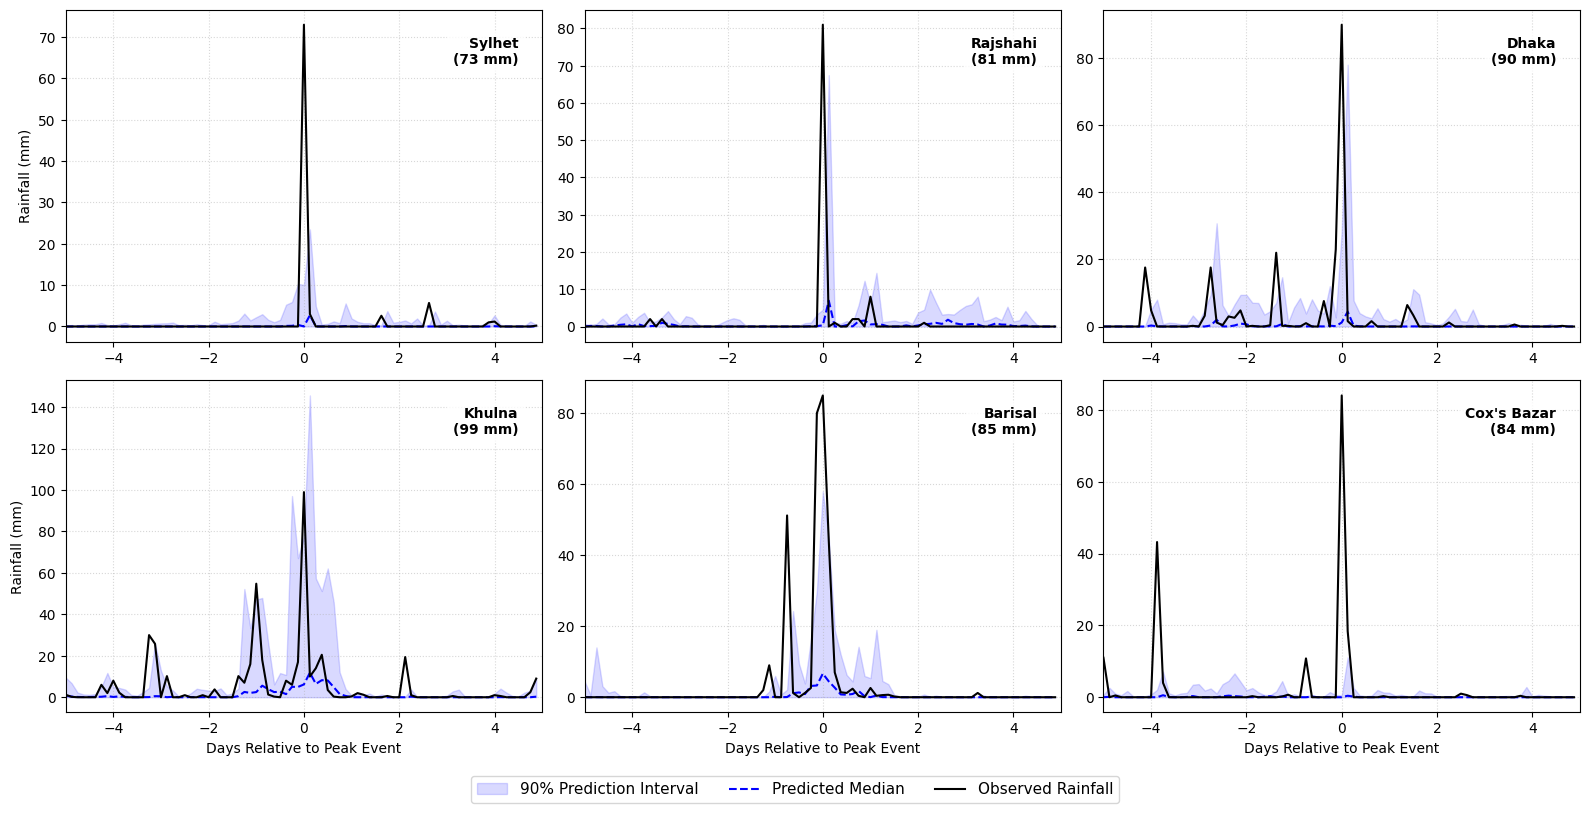

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ==========================================
# 1. Configuration & Ordering
# ==========================================
FILE_PATH = "test_predictions.npz"

SELECTED_STATIONS = [
    'Sylhet', 'Rajshahi', 'Dhaka',
    'Khulna', 'Barisal', "Cox's Bazar"
]

name_map = {
    'Barisal': 'Barishal',
    "Cox's Bazar": "Cox'sBazar"
}

try:
    data = np.load(FILE_PATH)

    # [FIX 1]: Hardcoded the station names so the script is standalone
    # (prevents crash from 'prep' not being defined)
    dataset_names = [
        'Ambagan(Ctg.)', 'Barishal', 'Bhola', 'Bogura', 'Chandpur', 'Chuadanga',
        "Cox'sBazar", 'Cumilla', 'Dhaka', 'Dinajpur', 'Faridpur', 'Feni', 'Hatiya',
        'Ishurdi', 'Jessore', 'Khepupara', 'Khulna', 'Kutubdia', 'Madaripur',
        'Maijdee_court', 'Mongla', 'Mymensingh', 'Patuakhali', 'Rajshahi',
        'Rangamati', 'Rangpur', 'Saidpur', 'Sandwip', 'Satkhira', 'Sitakunda',
        'Srimangal', 'Sylhet', 'Tangail', 'Teknaf'
    ]
    name_to_idx = {name: i for i, name in enumerate(dataset_names)}

    y_mm = np.expm1(data['y_log'][:, 0, :])

    # [FIX 2]: Adjusted indices for the 7-quantile output
    # Array: [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
    q10_all = np.expm1(data['q_hat'][:, 0, :, 1]) # Index 1 = 0.10
    q50_all = np.expm1(data['q_hat'][:, 0, :, 3]) # Index 3 = 0.50
    q90_all = np.expm1(data['q_hat'][:, 0, :, 5]) # Index 5 = 0.90

except Exception as e:
    print(f"Error: {e}")
    exit()

# ==========================================
# 2. Setup Subplots
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, display_name in enumerate(SELECTED_STATIONS):
    ax = axes[i]
    actual_name = name_map.get(display_name, display_name)
    idx = name_to_idx[actual_name]

    obs_series = y_mm[:, idx]
    peak_idx = np.argmax(obs_series)

    # 40 steps = 5 days (40 * 3h / 24h = 5)
    window = 40
    start, end = max(0, peak_idx - window), min(len(obs_series), peak_idx + window)

    # --- CONVERSION TO DAYS CENTERED AT 0 ---
    # Create x-axis in days, relative to the peak (peak becomes 0)
    x_steps = np.arange(end - start) - (peak_idx - start)
    x_days = (x_steps * 3) / 24  # Convert 3h steps to 24h days

    # Plotting
    ax.fill_between(x_days, q10_all[start:end, idx], q90_all[start:end, idx],
                    color='blue', alpha=0.15, label='90% Prediction Interval')
    ax.plot(x_days, q50_all[start:end, idx], 'b--', linewidth=1.5, label='Predicted Median')
    ax.plot(x_days, obs_series[start:end], 'k-', linewidth=1.5, label='Observed Rainfall')

    # Label (Top Right)
    peak_val = obs_series[peak_idx]
    ax.text(0.95, 0.92, f"{display_name}\n({peak_val:.0f} mm)",
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            va='top', ha='right', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Axis Formatting
    if i >= 3: ax.set_xlabel("Days Relative to Peak Event", fontsize=10)
    if i % 3 == 0: ax.set_ylabel("Rainfall (mm)", fontsize=10)

    ax.set_xlim(-5, 5) # Strictly show 5 days before and 5 days after
    ax.grid(True, linestyle=':', alpha=0.5)

# Global Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 1])
save_path = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Key_Station_Case_Studies_Days.pdf"
# Ensure the path is correct depending on whether you run locally or on Colab
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

# **Calibaration**

Using device: cpu
Checkpoint path: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_best_model.pt
Log path       : /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_epoch_log.csv

Loaded checkpoint:
  best_val_CRPS_log: 0.1258
  best_epoch       : 18
Total stations: 34
Total unique times: 61360

Split:
  Train: 0 → 42952
  Val:   42952 → 52156
  Test:  52156 → 61360
Validation dataset size: 9173
Test dataset size: 9173
Input feature dim: 18

Model rebuilt and weights loaded.
Evaluating and generating /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/test_predictions.npz...


/tmp/ipykernel_40400/3824596908.py:384: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


Saved /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/test_predictions.npz successfully.

========== RAW TEST METRICS (BEFORE CALIBRATION) ==========
CRPS_log   : 0.1068
CRPS_mm    : 0.5726
Brier_flash: 0.1060
Brier_peak : 0.1345
Brier_acc  : 0.1247

[Deterministic] Mean MAE:  0.6665 mm
[Deterministic] Mean RMSE: 3.9633 mm
(MAE per 3h step: [0.6469877362251282, 0.6631993055343628, 0.665913462638855, 0.6681055426597595, 0.6704375743865967, 0.6741873621940613, 0.6720117330551147, 0.6714265942573547])
(RMSE per 3h step: [3.8643534183502197, 3.9345364570617676, 3.956847906112671, 3.9741830825805664, 3.9844372272491455, 3.9926700592041016, 3.9972245693206787, 4.002303123474121])

[Flash 3h] PR-AUC=0.4126, ROC-AUC=0.9224
  @Thr=0.5: CSI=0.1853, POD=0.8416, FAR=0.8080

[Peak 24h] PR-AUC=0.6209, ROC-AUC=0.8832
  @Thr=0.5: CSI=0.4211, POD=0.8400, FAR=0.5422

[Acc 24h] PR-AUC=0.2673, ROC-AUC=0.8792
  @Thr=0.5: CSI=0.1386, POD=0.7808, FAR=0.8558

========== PER

/tmp/ipykernel_40400/3824596908.py:384: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
/tmp/ipykernel_40400/3824596908.py:971: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



========== CALIBRATION METRICS FOR REVIEWER RESPONSE ==========
Event Type                | Old BS   -> New BS   | Old ECE  -> New ECE 
---------------------------------------------------------------------------
Short-Duration Extreme Rainfall (3h) | 0.1063   -> 0.0318   | 0.3759   -> 0.0209
Peak Exceedance (24h)     | 0.1349   -> 0.1041   | 0.1883   -> 0.0139
Accumulation (24h)        | 0.1250   -> 0.0349   | 0.3833   -> 0.0345

IEEE compliant reliability diagram saved to: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/Reliability_Diagrams_All_Events.pdf

Loaded epoch log with 28 rows.


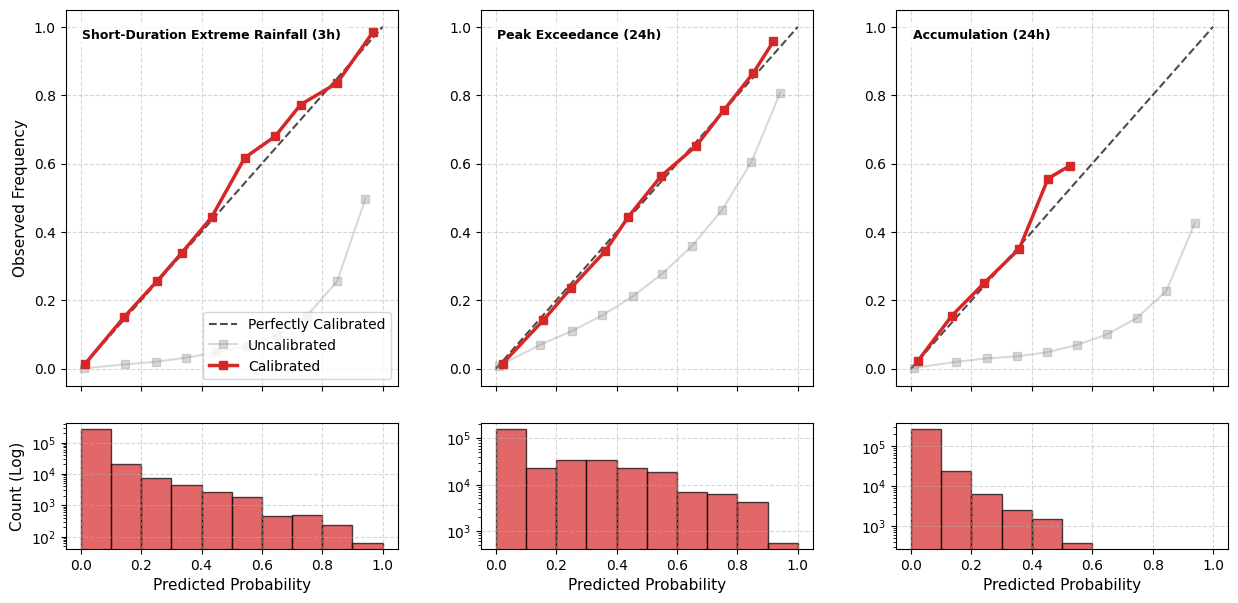

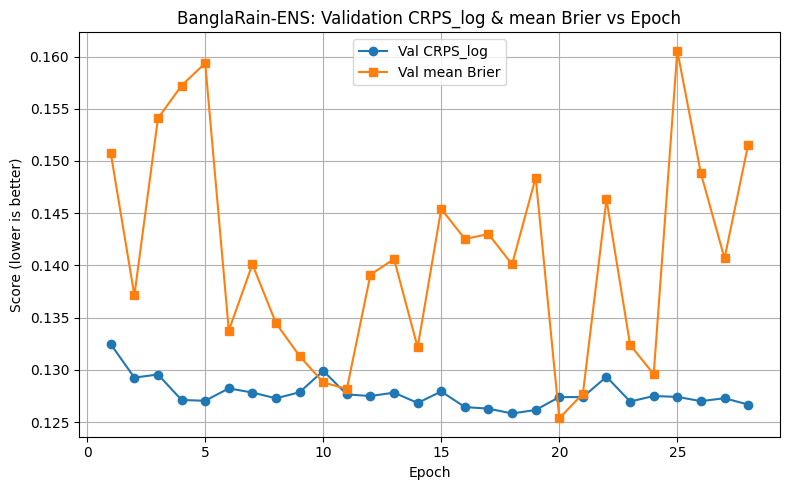

In [ ]:
# ============================================================
# BanglaRain-ENS — Standalone TESTING & CALIBRATION Script
# Reload final_best_model.pt, rebuild datasets/model, evaluate
# on TEST split, plot CRPS / Brier vs epoch, AND calibrate.
# ============================================================

import math
import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.nn import GATConv
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

import matplotlib.pyplot as plt


# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1) Utilities
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_knn_graph(stations_df, k=4):
    lat = stations_df["Latitude"].values
    lon = stations_df["Longitude"].values
    node_idx = stations_df["node_index"].values
    n = len(stations_df)

    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        dist_mat[i] = haversine(lat[i], lon[i], lat, lon)

    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.add((u, v))
            edge_list.add((v, u))

    edge_index_np = np.array(list(edge_list)).T
    return edge_index_np


class NaNIgnoringStandardScaler:
    """Standardize features ignoring NaNs in fit; keep NaNs in transform."""
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()

        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)

        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }


# ============================================================
# 2) Preprocessing (FULL GRID, missingness-aware)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()

    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N = len(stations)
    print("Total stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Total unique times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"]
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]

    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y = M_in[..., rain_idx]

    # time cyclical: hour + month
    dt_index = pd.DatetimeIndex(times)
    hour = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack([hour_sin, hour_cos, month_sin, month_cos], axis=-1).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    # Season (time-level)
    season_by_time = (
        df.groupby("Datetime")["Season"]
          .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
          .reindex(times)
          .astype(str)
          .values
    )
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    season_ids = np.array([season_to_id[s] for s in season_by_time], dtype=np.int64)

    return {
        "stations": stations,
        "stationid_to_node": stationid_to_node,
        "node_to_stationid": node_to_stationid,
        "times": times,
        "X_raw": X_raw,
        "M_in": M_in,
        "Y_rain": Y_rain,
        "M_y": M_y,
        "meteo_cols": meteo_cols,
        "time_feats": time_feats,
        "season_ids": season_ids,
        "unique_seasons": unique_seasons,
        "season_to_id": season_to_id,
    }


# ============================================================
# 3) Train/Val/Test split + train-only scaling
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end = int(T * (train_frac + val_frac))
    return train_end, val_end


def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled = X_scaled_flat.reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler


# ============================================================
# 4) Targets: thresholds + Acc24
# ============================================================

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q*100)
    return thr


def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)

    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok] = window[:, ok].sum(axis=0)
    return Acc, Mask


# ============================================================
# 5) Dataset (missingness-aware)
# ============================================================

class BanglaRainDataset(Dataset):
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        season_ids,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.season_ids = season_ids
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)

        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        regime_id = int(self.season_ids[t])

        return (
            torch.from_numpy(x_all),
            torch.tensor(regime_id, dtype=torch.long),
            torch.from_numpy(y_log),
            torch.from_numpy(my),
            torch.from_numpy(flash),
            torch.from_numpy(mflash),
            torch.from_numpy(peak24),
            torch.from_numpy(mpeak),
            torch.from_numpy(acc24),
            torch.from_numpy(macc),
        )


# ============================================================
# 6) Model (FULL MODEL WITH REGIME EMBEDDING)
# ============================================================

class BanglaRainENS(nn.Module):
    def __init__(
        self,
        num_stations,
        in_features,
        T_in,
        H_out,
        num_seasons,
        quantiles=(0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95),
        d_model=96,
        n_heads=4,
        num_temporal_layers=2,
        num_gat_layers=2,
        gat_heads=2,
        dropout=0.1,
    ):
        super().__init__()
        self.N = num_stations
        self.T_in = T_in
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_temporal_layers)

        self.regime_embedding = nn.Embedding(num_seasons, d_model)

        self.gat_layers = nn.ModuleList([
            GATConv(
                in_channels=d_model,
                out_channels=d_model,
                heads=gat_heads,
                concat=False,
                dropout=dropout,
            )
            for _ in range(num_gat_layers)
        ])

        # Quantile head (log-rain): H_out * K per node
        self.q_head = nn.Linear(d_model, H_out * self.K)

        # Risk heads
        self.flash_head = nn.Linear(d_model, 1)
        self.peak_head  = nn.Linear(d_model, 1)
        self.acc_head   = nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        """
        x: [B,T_in,N,F]
        regime_id: [B]
        edge_index: [2,E]
        """
        B, T, N, F_in = x.shape
        assert T == self.T_in and N == self.N

        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]

        # temporal per station
        h = h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model)
        h = self.temporal_encoder(h)
        h_last = h[:, -1, :].reshape(B, N, self.d_model)

        # regime conditioning
        reg = self.regime_embedding(regime_id)
        reg = reg[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg

        # batched graph edges
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_index = edge_index.to(x_nodes.device)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = gat(g, edge_batch)
            g = F.relu(g + g_in)
        g = g.reshape(B, N, self.d_model)

        # Quantiles (log-rain) — DO NOT SORT
        q = self.q_head(g)
        q = q.view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()

        flash_logits = self.flash_head(g).squeeze(-1)
        peak_logits  = self.peak_head(g).squeeze(-1)
        acc_logits   = self.acc_head(g).squeeze(-1)

        return q, flash_logits, peak_logits, acc_logits


# ============================================================
# 7) Evaluation function
# ============================================================

@torch.no_grad()
def evaluate(model, loader, edge_index, quantiles, device, thresholds=(0.1,0.2,0.3,0.4,0.5), save_path="test_predictions.npz"):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    save_q_hat = []
    save_y_log = []
    save_flash_p = []
    save_flash_y = []

    station_crps_sum = {}
    station_count_n = {}

    print(f"Evaluating and generating {save_path}...")

    for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x = x.to(device)
        reg = reg.to(device)
        edge_index = edge_index.to(device)
        y_log = y_log.to(device)
        my = my.to(device)
        flash = flash.to(device)
        mflash = mflash.to(device)
        peak = peak.to(device)
        mpeak = mpeak.to(device)
        acc = acc.to(device)
        macc = macc.to(device)

        q_hat, flash_logits, peak_logits, acc_logits = model(x, reg, edge_index)

        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        p_flash = torch.sigmoid(flash_logits)
        p_peak  = torch.sigmoid(peak_logits)
        p_acc   = torch.sigmoid(acc_logits)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()
        nb += 1

        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)
        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

        q_hat_np = q_hat.detach().cpu().numpy()
        y_log_np = y_log.detach().cpu().numpy()
        mask_np  = my.detach().cpu().numpy()

        save_q_hat.append(q_hat_np)
        save_y_log.append(y_log_np)
        save_flash_p.append(p_flash.detach().cpu().numpy())
        save_flash_y.append(flash.detach().cpu().numpy())

        for n_idx in range(N):
            valid = mask_np[:, :, n_idx] > 0.5
            if not valid.any(): continue

            loss_batch = 0
            cnt_batch = 0
            for k_idx, q_val in enumerate(quantiles):
                e = y_log_np[:, :, n_idx] - q_hat_np[:, :, n_idx, k_idx]
                loss = np.maximum((q_val - 1.0) * e, q_val * e)
                loss = loss * valid
                loss_batch += loss.sum()
                cnt_batch += valid.sum()

            if n_idx not in station_crps_sum:
                station_crps_sum[n_idx] = 0.0
                station_count_n[n_idx] = 0
            station_crps_sum[n_idx] += (loss_batch * 2.0)
            station_count_n[n_idx] += cnt_batch

    full_q_hat = np.concatenate(save_q_hat, axis=0)
    full_y_log = np.concatenate(save_y_log, axis=0)
    full_flash_p = np.concatenate(save_flash_p, axis=0)
    full_flash_y = np.concatenate(save_flash_y, axis=0)

    station_crps_final = []
    for n_idx in range(len(station_crps_sum)):
        if station_count_n.get(n_idx, 0) > 0:
            station_crps_final.append(station_crps_sum[n_idx] / station_count_n[n_idx])
        else:
            station_crps_final.append(np.nan)

    np.savez(save_path,
             q_hat=full_q_hat,
             y_log=full_y_log,
             flash_p=full_flash_p.flatten(),
             flash_y=full_flash_y.flatten(),
             station_crps=np.array(station_crps_final))
    print(f"Saved {save_path} successfully.")

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()
    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()
    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)

    return out


# ============================================================
# 8) Reload final model, rebuild VAL & TEST sets (No Leakage)
# ============================================================

FINAL_SAVE_DIR =  "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2"

CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")
LOG_PATH  = os.path.join(FINAL_SAVE_DIR, "final_epoch_log.csv")

print("Checkpoint path:", CKPT_PATH)
print("Log path       :", LOG_PATH)

# ---- 8.1 Load checkpoint + hparams ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

hp = ckpt["hparams"]
state_dict = ckpt["state_dict"]

print("\nLoaded checkpoint:")
print(f"  best_val_CRPS_log: {ckpt['best_val_CRPS_log']:.4f}")
print(f"  best_epoch       : {ckpt['best_epoch']}")

# ---- 8.2 Extract Frozen Train-Set Statistics (PREVENTS DATA LEAKAGE) ----
saved_mean = ckpt["scaler_mean"]
saved_std = ckpt["scaler_std"]
thr3h_saved = ckpt["thr3h"]
thrAcc24_saved = ckpt["thrAcc24"]

# ---- 8.3 Rebuild preprocessing + VAL & TEST datasets ----
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

print("\nSplit:")
print("  Train: 0 →", train_end)
print("  Val:  ", train_end, "→", val_end)
print("  Test: ", val_end, "→", T)

# --- APPLY FROZEN SCALER ---
X_flat = prep["X_raw"].reshape(T*N, prep["X_raw"].shape[-1])
scaler = NaNIgnoringStandardScaler()
# Manually inject the saved parameters to guarantee no validation/test leakage
scaler.mean_ = saved_mean
scaler.std_ = saved_std

X_scaled_flat = scaler.transform(X_flat)
X_scaled = X_scaled_flat.reshape(T, N, prep["X_raw"].shape[-1]).astype(np.float32)

# --- APPLY FROZEN THRESHOLDS ---
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))

# Build VAL dataset (Needed for Isotonic Calibration)
ds_val = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h_saved, thrAcc24_saved,  # Using the frozen thresholds!
    t_start=train_end, t_end=val_end,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)
val_loader = DataLoader(ds_val, batch_size=int(hp["batch_size"]), shuffle=False)


# Build TEST dataset using the saved thresholds
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h_saved, thrAcc24_saved,  # Using the frozen thresholds!
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test, batch_size=int(hp["batch_size"]), shuffle=False)

print("Validation dataset size:", len(ds_val))
print("Test dataset size:", len(ds_test))

# Infer input feature dim from one batch
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print("Input feature dim:", F_in)

# ---- 8.4 Rebuild model and load weights ----
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("\nModel rebuilt and weights loaded.")

# ---- 8.5 Evaluate on TEST set ----
with torch.no_grad():
    test_scores = evaluate(
        model,
        test_loader,
        edge_index,
        quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
        device=device,
        save_path=os.path.join(FINAL_SAVE_DIR, "test_predictions.npz")
    )

print("\n========== RAW TEST METRICS (BEFORE CALIBRATION) ==========")
print(f"CRPS_log   : {test_scores['CRPS_log']:.4f}")
print(f"CRPS_mm    : {test_scores['CRPS_mm']:.4f}")
print(f"Brier_flash: {test_scores['Brier_flash']:.4f}")
print(f"Brier_peak : {test_scores['Brier_peak']:.4f}")
print(f"Brier_acc  : {test_scores['Brier_acc']:.4f}")

# Print MAE and RMSE
maes = test_scores["MAE_mm_by_lead"]
rmses = test_scores["RMSE_mm_by_lead"]
print(f"\n[Deterministic] Mean MAE:  {np.nanmean(maes):.4f} mm")
print(f"[Deterministic] Mean RMSE: {np.nanmean(rmses):.4f} mm")
print(f"(MAE per 3h step: {maes})")
print(f"(RMSE per 3h step: {rmses})")

# Print CSI, POD, FAR
target_thr = 0.5

fm = test_scores["Flash_metrics"]
pm = test_scores["Peak24_metrics"]
am = test_scores["Acc24_metrics"]

def print_event_metrics(name, metrics, thr):
    print(f"\n[{name}] PR-AUC={metrics['pr_auc']:.4f}, ROC-AUC={metrics['roc_auc']:.4f}")
    if thr in metrics["by_thr"]:
        m = metrics["by_thr"][thr]
        print(f"  @Thr={thr}: CSI={m['CSI']:.4f}, POD={m['POD']:.4f}, FAR={m['FAR']:.4f}")
    else:
        print(f"  @Thr={thr}: Metrics not found")

print_event_metrics("Flash 3h", fm, target_thr)
print_event_metrics("Peak 24h", pm, target_thr)
print_event_metrics("Acc 24h",  am, target_thr)


# ============================================================
# 9) ISOTONIC CALIBRATION (Reviewer 1 Requirement)
# ============================================================
print("\n========== PERFORMING ISOTONIC CALIBRATION ==========")
print("Extracting predictions from Validation and Test sets to prevent data leakage...")

def get_probs_and_truths(loader):
    """Runs the model over a loader and returns masked probabilities and true labels."""
    flash_p, flash_y = [], []
    peak_p, peak_y = [], []
    acc_p, acc_y = [], []

    with torch.no_grad():
        for (x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
            x = x.to(device)
            reg = reg.to(device)
            edge_idx_dev = edge_index.to(device)

            # Forward pass
            _, f_logits, p_logits, a_logits = model(x, reg, edge_idx_dev)

            # Convert to probabilities
            f_prob = torch.sigmoid(f_logits).cpu().numpy()
            p_prob = torch.sigmoid(p_logits).cpu().numpy()
            a_prob = torch.sigmoid(a_logits).cpu().numpy()

            # Filter out missing data using masks
            mf = mflash.numpy() > 0.5
            mp = mpeak.numpy() > 0.5
            ma = macc.numpy() > 0.5

            flash_p.extend(f_prob[mf])
            flash_y.extend(flash.numpy()[mf])

            peak_p.extend(p_prob[mp])
            peak_y.extend(peak.numpy()[mp])

            acc_p.extend(a_prob[ma])
            acc_y.extend(acc.numpy()[ma])

    return (np.array(flash_p), np.array(flash_y)), \
           (np.array(peak_p), np.array(peak_y)), \
           (np.array(acc_p), np.array(acc_y))

# --- 1. Get raw probabilities ---
val_flash, val_peak, val_acc = get_probs_and_truths(val_loader)
test_flash, test_peak, test_acc = get_probs_and_truths(test_loader)

events = [
    ('Short-Duration Extreme Rainfall (3h)', val_flash, test_flash),
    ('Peak Exceedance (24h)', val_peak, test_peak),
    ('Accumulation (24h)', val_acc, test_acc)
]

# --- 2. Setup Figure ---
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1], hspace=0.15, wspace=0.25)
metrics_summary = []

# --- 3. Calibrate and Plot ---
for i, (title, val_data, test_data) in enumerate(events):
    val_p, val_y = val_data
    test_p, test_y = test_data

    # A. Fit Isotonic Regression on VALIDATION SET
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(val_p, val_y)

    # B. Apply Correction to TEST SET
    test_p_calibrated = iso.predict(test_p)

    # C. Compute Metrics
    bs_uncal = brier_score_loss(test_y, test_p)
    bs_cal = brier_score_loss(test_y, test_p_calibrated)

    orig_true, orig_pred = calibration_curve(test_y, test_p, n_bins=10)
    cal_true, cal_pred = calibration_curve(test_y, test_p_calibrated, n_bins=10)

    ece_uncal = np.abs(orig_true - orig_pred).mean()
    ece_cal = np.abs(cal_true - cal_pred).mean()

    metrics_summary.append({
        "Event": title,
        "BS_Uncal": bs_uncal, "BS_Cal": bs_cal,
        "ECE_Uncal": ece_uncal, "ECE_Cal": ece_cal
    })

    # D. Plotting
    ax1 = fig.add_subplot(gs[0, i])
    ax2 = fig.add_subplot(gs[1, i], sharex=ax1)

    ax1.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated", alpha=0.7)
    ax1.plot(orig_pred, orig_true, "s-", color="gray", alpha=0.3, label="Uncalibrated")
    ax1.plot(cal_pred, cal_true, "s-", color="#d62728", linewidth=2.5, label="Calibrated")

    if i == 0:
        ax1.set_ylabel("Observed Frequency", fontsize=11)
    ax1.set_ylim([-0.05, 1.05])

    ax1.text(0.05, 0.95, title, transform=ax1.transAxes, fontsize=9, fontweight='bold', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    if i == 0:
        ax1.legend(loc="lower right", fontsize=10, frameon=True)
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2.hist(test_p_calibrated, range=(0, 1), bins=10, color="#d62728", alpha=0.7, edgecolor="black")
    ax2.set_xlabel("Predicted Probability", fontsize=11)
    if i == 0:
        ax2.set_ylabel("Count (Log)", fontsize=11)
    ax2.set_yscale("log")
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.setp(ax1.get_xticklabels(), visible=False)

# --- 4. Final Output ---
plt.tight_layout()
save_path = os.path.join(FINAL_SAVE_DIR, "Reliability_Diagrams_All_Events.pdf")
plt.savefig(save_path, bbox_inches='tight', dpi=300)

print("\n========== CALIBRATION METRICS FOR REVIEWER RESPONSE ==========")
print(f"{'Event Type':<25} | {'Old BS':<8} -> {'New BS':<8} | {'Old ECE':<8} -> {'New ECE':<8}")
print("-" * 75)
for m in metrics_summary:
    print(f"{m['Event']:<25} | {m['BS_Uncal']:.4f}   -> {m['BS_Cal']:.4f}   | {m['ECE_Uncal']:.4f}   -> {m['ECE_Cal']:.4f}")
print(f"\nIEEE compliant reliability diagram saved to: {save_path}")

# ---- 8.6 Plot learning curves from final_epoch_log.csv ----
log_df = pd.read_csv(LOG_PATH)
print("\nLoaded epoch log with {} rows.".format(len(log_df)))

log_df["mean_brier"] = log_df[["val_Brier_flash", "val_Brier_peak", "val_Brier_acc"]].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(log_df["epoch"], log_df["val_CRPS_log"], marker="o", label="Val CRPS_log")
plt.plot(log_df["epoch"], log_df["mean_brier"], marker="s", label="Val mean Brier")
plt.xlabel("Epoch")
plt.ylabel("Score (lower is better)")
plt.title("BanglaRain-ENS: Validation CRPS_log & mean Brier vs Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-1334172445.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


IEEE compliant reliability diagram saved to: /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Reliability_Diagram_Final.pdf
Final ECE: 0.0235


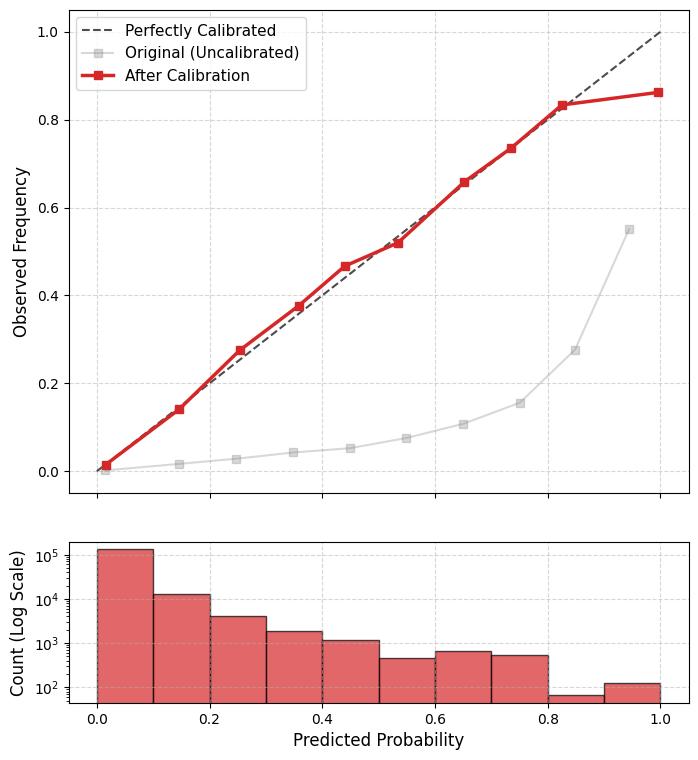

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

def plot_calibrated_reliability(data):
    """
    Splits test data to learn a calibration map, then plots the corrected diagram.
    Internal title removed for IEEE Access compliance.
    """
    # 1. Get Data
    y_probs = data['flash_p']
    y_true  = data['flash_y']

    # 2. Split Data (50% for Calibration, 50% for Evaluation)
    n = len(y_probs)
    mid = n // 2

    probs_train = y_probs[:mid]
    y_train     = y_true[:mid]

    probs_test  = y_probs[mid:]
    y_test      = y_true[mid:]

    # 3. Fit Isotonic Regression (The "Calibrator")
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(probs_train, y_train)

    # 4. Apply Correction
    probs_calibrated = iso.predict(probs_test)

    # 5. Compute New Calibration Curve & ECE
    prob_true, prob_pred = calibration_curve(y_test, probs_calibrated, n_bins=10)
    ece = np.abs(prob_true - prob_pred).mean()

    # --- PLOTTING ---
    fig = plt.figure(figsize=(8, 9))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.15)

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # Top Plot: Curve
    ax1.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated", alpha=0.7)

    # Plot Original (Faint)
    orig_true, orig_pred = calibration_curve(y_test, probs_test, n_bins=10)
    ax1.plot(orig_pred, orig_true, "s-", color="gray", alpha=0.3, label="Original (Uncalibrated)")

    # Plot Calibrated (Bold Red)
    ax1.plot(prob_pred, prob_true, "s-", color="#d62728", linewidth=2.5, label="After Calibration")

    ax1.set_ylabel("Observed Frequency", fontsize=12)
    ax1.set_ylim([-0.05, 1.05])

    # REMOVED: Internal ax1.set_title for IEEE compliance

    ax1.legend(loc="upper left", fontsize=11, frameon=True)
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Bottom Plot: Histogram
    ax2.hist(probs_calibrated, range=(0, 1), bins=10, color="#d62728", alpha=0.7, edgecolor="black")
    ax2.set_xlabel("Predicted Probability", fontsize=12)
    ax2.set_ylabel("Count (Log Scale)", fontsize=12)
    ax2.set_yscale("log")
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.setp(ax1.get_xticklabels(), visible=False)

    plt.tight_layout()
    save_path = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/BanglaRainENS/Reliability_Diagram_Final.pdf"
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"IEEE compliant reliability diagram saved to: {save_path}")
    print(f"Final ECE: {ece:.4f}")
    plt.show()

# Run the function
plot_calibrated_reliability(data)

# **XAI: Extracts and visualizes TRUE Graph Attention weights**

In [ ]:
num_stations=34

Using device: cpu

Loading Checkpoint: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2/final_best_model.pt
Input feature dim: 18
✅ Model loaded successfully!

XAI ANALYSIS FOR BANGLARAIN-ENS

Visualizing actual GAT attention...
Graph attention plot saved to: /content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/XAI/graph_attention.pdf


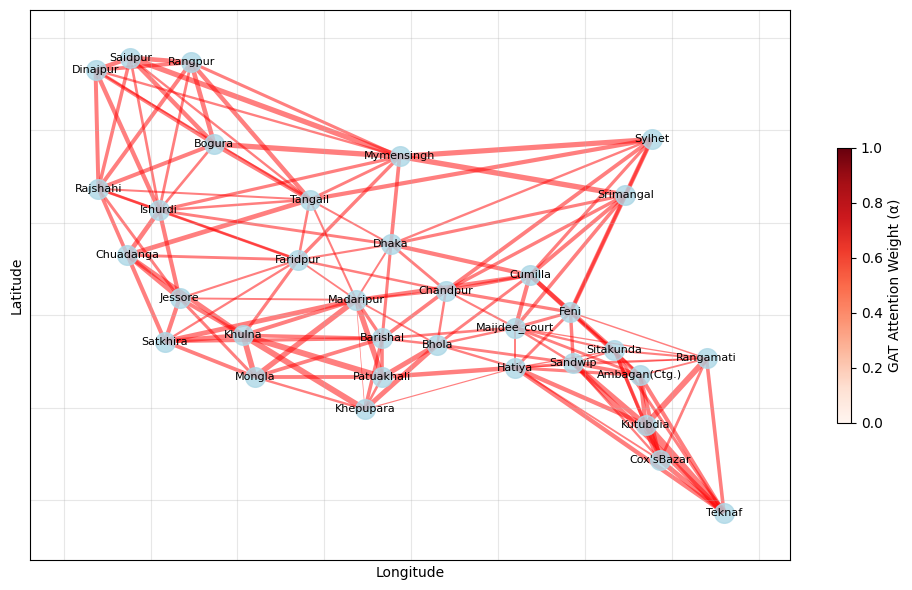


TOP 10 MOST ATTENDED STATION PAIRS (TRUE α WEIGHTS)
 1. Kutubdia        ↔ Teknaf          : 0.8053
 2. Kutubdia        ↔ Cox'sBazar      : 0.7358
 3. Kutubdia        ↔ Ambagan(Ctg.)   : 0.6208
 4. Kutubdia        ↔ Sandwip         : 0.6154
 5. Chuadanga       ↔ Satkhira        : 0.6062
 6. Cumilla         ↔ Srimangal       : 0.5880
 7. Kutubdia        ↔ Rangamati       : 0.5614
 8. Chuadanga       ↔ Khulna          : 0.5540
 9. Rangpur         ↔ Bogura          : 0.5478
10. Rangpur         ↔ Saidpur         : 0.5445

✅ XAI analysis complete!


In [ ]:
# ============================================================
# XAI: Complete Analysis for BanglaRain-ENS (k=7)
# Extracts and visualizes TRUE Graph Attention weights (α)
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv

import matplotlib.pyplot as plt
import networkx as nx

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 1) Utilities & Preprocessing
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_knn_graph(stations_df, k=4):
    lat, lon = stations_df["Latitude"].values, stations_df["Longitude"].values
    node_idx, n = stations_df["node_index"].values, len(stations_df)
    dist_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n): dist_mat[i] = haversine(lat[i], lon[i], lat, lon)
    edge_list = set()
    for i in range(n):
        neighbours = np.argsort(dist_mat[i])[1:k+1]
        for j in neighbours:
            u, v = int(node_idx[i]), int(node_idx[j])
            edge_list.update([(u, v), (v, u)])
    return np.array(list(edge_list)).T

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8): self.eps = eps
    def fit(self, X):
        self.mean_, self.std_ = np.nanmean(X, axis=0), np.nanstd(X, axis=0)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self
    def transform(self, X): return (X - self.mean_) / self.std_

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)
    dr_rad = np.deg2rad(df["DR"].astype(np.float32).to_numpy())
    df["DR_sin"], df["DR_cos"] = np.sin(dr_rad), np.cos(dr_rad)
    stations = df[["StationID", "StationName", "Latitude", "Longitude"]].drop_duplicates().sort_values("StationID").reset_index(drop=True)
    stations["node_index"] = np.arange(len(stations))
    stationid_to_node = dict(zip(stations["StationID"], stations["node_index"]))
    node_to_stationid = dict(zip(stations["node_index"], stations["StationID"]))
    N, times = len(stations), np.sort(df["Datetime"].unique())
    T = len(times)

    full_index = pd.MultiIndex.from_product([times, stations["StationID"].values], names=["Datetime", "StationID"])
    meteo_cols = ["DewPointTemperature", "StationLevelPressure", "SP", "Humidity", "Rainfall", "DR_sin", "DR_cos"]
    X_raw = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index().reindex(full_index).values.reshape(T, N, len(meteo_cols)).astype(np.float32)
    M_in = (~np.isnan(X_raw)).astype(np.float32)
    Y_rain, M_y = X_raw[..., meteo_cols.index("Rainfall")], M_in[..., meteo_cols.index("Rainfall")]

    dt_index = pd.DatetimeIndex(times)
    hour, month = dt_index.hour.astype(np.float32), dt_index.month.astype(np.float32)
    time_feats = np.repeat(np.stack([np.sin(2*np.pi*(hour/24.0)), np.cos(2*np.pi*(hour/24.0)), np.sin(2*np.pi*((month-1)/12.0)), np.cos(2*np.pi*((month-1)/12.0))], axis=-1).astype(np.float32)[:, None, :], N, axis=1)

    season_by_time = df.groupby("Datetime")["Season"].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]).reindex(times).astype(str).values
    unique_seasons = sorted(pd.unique(season_by_time))
    season_to_id = {s: i for i, s in enumerate(unique_seasons)}
    return {"stations": stations, "stationid_to_node": stationid_to_node, "node_to_stationid": node_to_stationid, "times": times, "X_raw": X_raw, "M_in": M_in, "Y_rain": Y_rain, "M_y": M_y, "meteo_cols": meteo_cols, "time_feats": time_feats, "season_ids": np.array([season_to_id[s] for s in season_by_time], dtype=np.int64), "unique_seasons": unique_seasons, "season_to_id": season_to_id}

def make_splits(T, train_frac=0.7, val_frac=0.15): return int(T * train_frac), int(T * (train_frac + val_frac))

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train, M_train, N = Y[:train_end], M[:train_end], Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)
    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q*100) if global_vals.size > 0 else 0.0
    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        thr[j] = np.nanpercentile(vals, q*100) if len(vals) >= 100 else global_fallback
    return thr

def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc, Mask = np.full((T, N), np.nan, dtype=np.float32), np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window, wmask = Y_rain[t+1:t+1+H_out], M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok], Acc[t, ok] = 1.0, window[:, ok].sum(axis=0)
    return Acc, Mask

def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T*N, F)
    train_flat = X_flat[:train_end*N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled = scaler.transform(X_flat).reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler

# ============================================================
# 2) Dataset & Model
# ============================================================
class BanglaRainDataset(Dataset):
    def __init__(self, X_scaled, M_in, time_feats, Y_rain, M_y, Acc24, MaskAcc24, season_ids, thr3h, thrAcc24, t_start, t_end, T_in=16, H_out=8, peak_min_obs=None):
        self.X_scaled, self.M_in, self.time_feats = X_scaled, M_in, time_feats
        self.Y_rain, self.M_y, self.Acc24, self.MaskAcc24 = Y_rain, M_y, Acc24, MaskAcc24
        self.season_ids, self.thr3h, self.thrAcc24 = season_ids, thr3h, thrAcc24
        self.T_in, self.H_out = T_in, H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)
        self.indices = list(range(t_start + (T_in - 1), t_end - H_out))

    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        t = self.indices[idx]
        x_all = np.concatenate([np.nan_to_num(self.X_scaled[t-self.T_in+1:t+1], nan=0.0).astype(np.float32), self.M_in[t-self.T_in+1:t+1].astype(np.float32), self.time_feats[t-self.T_in+1:t+1]], axis=-1)
        y_win, m_win = self.Y_rain[t+1:t+1+self.H_out], self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y_win, nan=0.0)).astype(np.float32)
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((self.Y_rain[t+1] >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        peak24 = ((np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0) >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((self.Acc24[t] >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)
        return torch.from_numpy(x_all), torch.tensor(int(self.season_ids[t]), dtype=torch.long), torch.from_numpy(y_log), torch.from_numpy(m_win), torch.from_numpy(flash), torch.from_numpy(m_next), torch.from_numpy(peak24), torch.from_numpy(mpeak), torch.from_numpy(acc24), torch.from_numpy(macc)

class BanglaRainENS(nn.Module):
    def __init__(self, num_stations, in_features, T_in, H_out, num_seasons, quantiles=(0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95), d_model=96, n_heads=4, num_temporal_layers=2, num_gat_layers=2, gat_heads=2, dropout=0.1):
        super().__init__()
        self.N, self.T_in, self.H_out, self.quantiles, self.K, self.d_model = num_stations, T_in, H_out, list(quantiles), len(quantiles), d_model
        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, T_in, 1, d_model) * 0.02)
        self.temporal_encoder = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model, dropout=dropout, batch_first=True), num_layers=num_temporal_layers)
        self.regime_embedding = nn.Embedding(num_seasons, d_model)
        self.gat_layers = nn.ModuleList([GATConv(in_channels=d_model, out_channels=d_model, heads=gat_heads, concat=False, dropout=dropout) for _ in range(num_gat_layers)])
        self.q_head = nn.Linear(d_model, H_out * self.K)
        self.flash_head, self.peak_head, self.acc_head = nn.Linear(d_model, 1), nn.Linear(d_model, 1), nn.Linear(d_model, 1)

    def forward(self, x, regime_id, edge_index):
        B, T, N, F_in = x.shape
        h = self.input_proj(x) + self.pos_embedding[:, :T, :, :]
        h = self.temporal_encoder(h.permute(0, 2, 1, 3).reshape(B*N, T, self.d_model))
        h_last = h[:, -1, :].reshape(B, N, self.d_model)
        reg = self.regime_embedding(regime_id)[:, None, :].expand(-1, N, -1)
        h_nodes = h_last + reg
        x_nodes = h_nodes.reshape(B*N, self.d_model)
        edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)
        g = x_nodes
        for gat in self.gat_layers:
            g_in = g
            g = F.relu(gat(g, edge_batch) + g_in)
        g = g.reshape(B, N, self.d_model)
        q = self.q_head(g).view(B, N, self.H_out, self.K).permute(0, 2, 1, 3).contiguous()
        return q, self.flash_head(g).squeeze(-1), self.peak_head(g).squeeze(-1), self.acc_head(g).squeeze(-1)

# ============================================================
# 3) XAI Visualization Function (CORRECTED)
# ============================================================
def visualize_graph_attention(model, test_loader, edge_index, device, stations_df, save_path=None):
    """
    Visualize ACTUAL GAT attention weights on station graph.
    IEEE Access compliant - no embedded title, actual station names.
    """
    model.eval()

    # Get one batch
    x, reg, y_log, my, flash, mflash, peak, mpeak, acc, macc = next(iter(test_loader))
    x = x.to(device)
    reg = reg.to(device)

    B, T, N, F = x.shape

    # Forward pass through model until GAT
    h = model.input_proj(x) + model.pos_embedding[:, :T, :, :]

    # Temporal encoder
    h = h.permute(0, 2, 1, 3).reshape(B*N, T, model.d_model)
    h = model.temporal_encoder(h)
    h_last = h[:, -1, :].reshape(B, N, model.d_model)

    # Regime conditioning
    reg_emb = model.regime_embedding(reg)[:, None, :].expand(-1, N, -1)
    h_nodes = h_last + reg_emb

    # Prepare for GAT
    x_nodes = h_nodes.reshape(B*N, model.d_model)
    edge_batch = torch.cat([edge_index + b*N for b in range(B)], dim=1)

    # Get original edges
    orig_edges = edge_index.cpu().numpy()
    num_orig_edges = orig_edges.shape[1]

    # Forward through GAT layers and capture EXACT attention
    edge_attention_sum = np.zeros(num_orig_edges)
    edge_count = 0

    for b in range(B):
        # Get edges for this batch
        batch_mask = (edge_batch.cpu()[0] >= b*N) & (edge_batch.cpu()[0] < (b+1)*N)
        batch_edges = edge_batch[:, batch_mask] - b*N

        # Get node features for this batch
        batch_nodes = x_nodes[b*N:(b+1)*N]

        # First GAT layer
        gat = model.gat_layers[0]

        # ---------------------------------------------------------
        # Extract exact attention weights (\alpha) from PyG GATConv
        # ---------------------------------------------------------
        _, (_, alpha) = gat(batch_nodes, batch_edges, return_attention_weights=True)

        # alpha shape is [num_edges, heads]. Average across attention heads.
        attn = alpha.mean(dim=-1).detach().cpu().numpy()

        # Map back to original edges
        for i, e in enumerate(batch_edges[0]):
            orig_edge_idx = i % num_orig_edges
            edge_attention_sum[orig_edge_idx] += attn[i]
            edge_count += 1

    # Average the attention over the batch
    edge_attention = edge_attention_sum / (edge_count / num_orig_edges + 1e-8)

    # Normalize between 0 and 1 for visualization
    if edge_attention.max() > edge_attention.min():
        edge_attention = (edge_attention - edge_attention.min()) / (edge_attention.max() - edge_attention.min() + 1e-8)

    # Create graph visualization
    plt.figure(figsize=(10, 6))

    # Get station coordinates
    pos = {i: (stations_df.iloc[i]['Longitude'], stations_df.iloc[i]['Latitude']) for i in range(N)}

    # Create networkx graph
    G = nx.Graph()
    for i in range(N):
        G.add_node(i, label=stations_df.iloc[i]['StationName'])

    # Add edges with attention weights
    for e in range(num_orig_edges):
        u, v = orig_edges[:, e]
        G.add_edge(u, v, weight=edge_attention[e])

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=200, node_color='lightblue', alpha=0.8)

    # Draw edges with varying thickness based on true attention
    edges = G.edges()
    weights = [G[u][v]['weight'] * 5 + 0.5 for u, v in edges]

    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, alpha=0.5, edge_color='red')

    # Draw labels with actual station names
    labels = {i: stations_df.iloc[i]['StationName'] for i in range(N)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    # NO TITLE - IEEE Access compliant
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, alpha=0.3)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.5)
    cbar.set_label('GAT Attention Weight (\u03B1)')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Graph attention plot saved to: {save_path}")
    plt.show()

    # Top edges with actual station names
    print("\n" + "="*60)
    print("TOP 10 MOST ATTENDED STATION PAIRS (TRUE \u03B1 WEIGHTS)")
    print("="*60)
    edge_attn_pairs = [(orig_edges[0, e], orig_edges[1, e], edge_attention[e])
                       for e in range(num_orig_edges)]
    edge_attn_pairs.sort(key=lambda x: x[2], reverse=True)

    # Average bidirectional edges (u,v) and (v,u)
    averaged_pairs = {}
    for u, v, attn in edge_attn_pairs:
        if (v, u) in averaged_pairs or (u, v) in averaged_pairs:
            continue
        # Find the reverse edge
        rev_attn = 0
        for u2, v2, a2 in edge_attn_pairs:
            if u2 == v and v2 == u:
                rev_attn = a2
                break
        avg_attn = (attn + rev_attn) / 2
        averaged_pairs[(u, v)] = avg_attn

    # Sort averaged pairs
    sorted_pairs = sorted(averaged_pairs.items(), key=lambda x: x[1], reverse=True)

    for i, ((u, v), attn) in enumerate(sorted_pairs[:10]):
        station_u = stations_df.iloc[u]['StationName']
        station_v = stations_df.iloc[v]['StationName']
        print(f"{i+1:2d}. {station_u:15s} ↔ {station_v:15s} : {attn:.4f}")

# ============================================================
# 4) Main Execution
# ============================================================

# Paths
FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/Final_Run_k7/v2" # Using your k7 v2 directory
CKPT_PATH = os.path.join(FINAL_SAVE_DIR, "final_best_model.pt")

print(f"\nLoading Checkpoint: {CKPT_PATH}")
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
hp = ckpt["hparams"]
state_dict = ckpt["state_dict"]

# Rebuild preprocessing
prep = prepare_full_grid(df_rain)
stations = prep["stations"]
N = len(stations)

# Graph
edge_index_np = build_knn_graph(stations, k=int(hp["k_nn"]))
edge_index = torch.tensor(edge_index_np, dtype=torch.long).to(device)

# Time splits
T = len(prep["times"])
train_end, val_end = make_splits(T, train_frac=0.7, val_frac=0.15)

# Scaling
X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)

# Thresholds
thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=int(hp["H_out"]))
thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

# Build TEST dataset
ds_test = BanglaRainDataset(
    X_scaled, prep["M_in"], prep["time_feats"],
    prep["Y_rain"], prep["M_y"],
    Acc24, MaskAcc24,
    prep["season_ids"],
    thr3h, thrAcc24,
    t_start=val_end, t_end=T,
    T_in=int(hp["T_in"]), H_out=int(hp["H_out"])
)

test_loader = DataLoader(ds_test, batch_size=int(hp["batch_size"]), shuffle=False)

# Infer input feature dim
x0, *_ = next(iter(test_loader))
F_in = x0.shape[-1]
print(f"Input feature dim: {F_in}")

# Rebuild model
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=int(hp["T_in"]),
    H_out=int(hp["H_out"]),
    num_seasons=len(prep["unique_seasons"]),
    quantiles=tuple(hp.get("quantiles", (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95))),
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    num_temporal_layers=int(hp["num_temporal_layers"]),
    num_gat_layers=int(hp["num_gat_layers"]),
    gat_heads=int(hp["gat_heads"]),
    dropout=float(hp["dropout"]),
).to(device)

model.load_state_dict(state_dict)
model.eval()

print("✅ Model loaded successfully!")

print("\n" + "="*60)
print("XAI ANALYSIS FOR BANGLARAIN-ENS")
print("="*60)

# Create output directory
XAI_DIR = "/content/drive/MyDrive/Rainfall/Updated Research Data/BanglaRainENS/XAI"
os.makedirs(XAI_DIR, exist_ok=True)
save_pdf_path = os.path.join(XAI_DIR, 'graph_attention.pdf')

print("\nVisualizing actual GAT attention...")
try:
    visualize_graph_attention(model, test_loader, edge_index, device, stations, save_path=save_pdf_path)
except Exception as e:
    print(f"Graph attention failed: {e}")

print("\n✅ XAI analysis complete!")